# EV Charging Demand Prediction and Usage Pattern Analysis Using Machine Learning

## Notebook Objective
This notebook implements an end-to-end station-hour time-series forecasting workflow for NYC municipal EV charging stations. It converts raw charging-session records into station-hour targets, engineers past-only temporal features, compares baseline and machine-learning models, evaluates future-period performance, and segments driver behavior for operational planning.

**Forecasting targets**
- `session_count`: active charging sessions per station-hour.
- `total_energy_kwh`: total energy consumed per station-hour.

**Additional analysis**
- Exploratory usage patterns, feature validation, model diagnostics, feature importance, seven-day demand forecasting, and user behavior clustering.


## 0. Setup and Configuration
This section imports required libraries, installs optional model packages when needed, defines global constants, configures paths, and creates the output directory used for figures, model tables, predictions, and forecast files.


In [30]:
# Quietly install required notebook dependencies.
import sys
import subprocess

packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'sodapy',
    'catboost',
    'lightgbm',
    'xgboost',
]

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])


0

In [31]:
from __future__ import annotations

import copy
import json
import os
import warnings
from pathlib import Path
from time import time
from typing import Any

os.environ.setdefault('MPLCONFIGDIR', str((Path.cwd() / '.cache' / 'matplotlib').resolve()))
os.environ.setdefault('XDG_CACHE_HOME', str((Path.cwd() / '.cache').resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sodapy import Socrata
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor



In [32]:
sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'time_series_forecast_notebook'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DOMAIN = 'data.cityofnewyork.us'
DATASET_ID = 'kj7g-u4gp'
TARGET = 'session_count'
ENERGY_TARGET = 'total_energy_kwh'
RANDOM_STATE = 42

NUMERIC_SESSION_COLUMNS = ['charge_duration_min', 'connected_duration_min', 'energy_provided_kwh']
COLUMN_RENAME_MAP = {
    'Date': 'date',
    'Station Name': 'station_name',
    'Location Name': 'location_name',
    'Connected Time': 'connected_time',
    'Disconnected Time': 'disconnected_time',
    'Charge Duration (min)': 'charge_duration_min',
    'Connected Duration (min)': 'connected_duration_min',
    'Energy Provided (kWh)': 'energy_provided_kwh',
    'Session Status': 'session_status',
    'Invalidity Reason': 'invalidity_reason',
}
CATEGORICAL_FEATURES = ['station_name', 'location_name']
SERIES_KEYS = ['station_name', 'location_name']

STATION_SESSION_LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 167, 168, 169, 336]
ROLLING_SESSION_WINDOWS = [6, 12, 24, 72, 168, 336]
EWM_SESSION_SPANS = [24, 72, 168]
GLOBAL_SESSION_LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
GLOBAL_ROLLING_WINDOWS = [24, 72, 168, 336]
ENERGY_LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
ENERGY_ROLLING_WINDOWS = [3, 6, 12, 24, 72, 168, 336]
MIN_FEATURE_NON_NULL_FRACTION = 0.15
MAX_SELECTED_NUMERIC_FEATURES = 100
ENERGY_MAX_SELECTED_NUMERIC_FEATURES = 9999
USE_ALL_AUDITED_ENERGY_FEATURES = True

print(f'Project root: {PROJECT_ROOT}')
print(f'Notebook output dir: {OUTPUT_DIR}')

Project root: /Users/alefew/Documents/New project
Notebook output dir: /Users/alefew/Documents/New project/outputs/time_series_forecast_notebook


## Helper Functions: Data Loading
These utilities load the EV charging data from a local CSV when available; otherwise, they retrieve records from the NYC Open Data API. A small column-checking helper is also defined to make later preprocessing steps safer.


In [33]:
def load_data(input_csv: Path | None = None, limit: int = 236_000) -> pd.DataFrame:
    if input_csv and input_csv.exists():
        df = pd.read_csv(input_csv)
        print(f'Loaded local CSV {input_csv}: {df.shape}')
        return df

    if Socrata is None:
        raise ImportError('sodapy is not installed and no local data/ev_charging.csv file was found.')

    client = Socrata(DATASET_DOMAIN, None)
    try:
        records = client.get(DATASET_ID, limit=limit)
    finally:
        client.close()
    df = pd.DataFrame.from_records(records)
    print(f'Downloaded {len(df):,} rows from NYC Open Data dataset {DATASET_ID}')
    return df


def require_columns(df: pd.DataFrame, columns: list[str]) -> None:
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')


## Helper Functions: Data Cleaning
These functions standardize raw column names, parse session start/end timestamps, handle overnight sessions, and remove missing or physically implausible charging records before modeling.


In [34]:
def parse_session_start(date_value: Any, time_value: Any) -> pd.Timestamp | pd.NaT:
    date = pd.to_datetime(date_value, errors='coerce')
    if pd.isna(date) or pd.isna(time_value):
        return pd.NaT

    time_text = str(time_value).strip()
    parsed_time = pd.to_datetime(time_text, errors='coerce')
    if pd.notna(parsed_time) and ('-' in time_text or '/' in time_text):
        return parsed_time

    parts = time_text.split(':')
    if len(parts) < 2:
        return pd.NaT

    try:
        hour = int(float(parts[0]))
        minute = int(float(parts[1]))
    except ValueError:
        return pd.NaT

    return date.normalize() + pd.Timedelta(hours=hour, minutes=minute)


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    clean_names = {col: col.strip().lower().replace(' ', '_') for col in df.columns}
    standardized = df.rename(columns=COLUMN_RENAME_MAP).rename(columns=clean_names)
    return standardized


def parse_session_timestamps(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    date_text = out['date'].astype(str).str.strip()
    date = pd.to_datetime(date_text, format='%m/%d/%Y', errors='coerce')
    missing_date = date.isna()
    if missing_date.any():
        date.loc[missing_date] = pd.to_datetime(date_text.loc[missing_date], errors='coerce', format='mixed')

    start_offset = pd.to_timedelta(out['connected_time'].astype(str).str.strip(), errors='coerce')
    end_offset = pd.to_timedelta(out['disconnected_time'].astype(str).str.strip(), errors='coerce')
    out['session_start'] = date + start_offset
    out['session_end'] = date + end_offset
    overnight = out['session_end'].notna() & out['session_start'].notna() & (out['session_end'] <= out['session_start'])
    out.loc[overnight, 'session_end'] = out.loc[overnight, 'session_end'] + pd.Timedelta(days=1)
    out['parsed_overnight_session'] = overnight.astype(int)
    return out


def clean_sessions(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, Any]]:
    clean = standardize_columns(df)
    required = ['date', 'connected_time', 'disconnected_time', 'station_name', 'location_name', *NUMERIC_SESSION_COLUMNS]
    require_columns(clean, required)

    input_rows = len(clean)
    clean = clean.drop_duplicates()
    duplicates_removed = input_rows - len(clean)

    for col in NUMERIC_SESSION_COLUMNS:
        clean[col] = pd.to_numeric(clean[col], errors='coerce')

    clean = parse_session_timestamps(clean)
    clean['station_name'] = clean['station_name'].astype(str).str.strip().replace({'': np.nan, 'nan': np.nan})
    clean['location_name'] = clean['location_name'].astype(str).str.strip().replace({'': np.nan, 'nan': np.nan})

    before_missing = len(clean)
    clean = clean.dropna(subset=['session_start', 'session_end', 'station_name', 'location_name', *NUMERIC_SESSION_COLUMNS])
    missing_removed = before_missing - len(clean)

    before_invalid = len(clean)
    clean = clean[clean['session_end'] > clean['session_start']]
    clean = clean[clean['energy_provided_kwh'] >= 0]
    clean = clean[clean['charge_duration_min'] > 0]
    clean = clean[clean['connected_duration_min'] > 0]
    clean = clean[clean['connected_duration_min'] >= clean['charge_duration_min']]
    clean['actual_connected_duration_min'] = (clean['session_end'] - clean['session_start']).dt.total_seconds() / 60
    clean = clean[clean['actual_connected_duration_min'].between(1, 7 * 24 * 60)]
    invalid_removed = before_invalid - len(clean)

    clean['date'] = clean['session_start'].dt.date
    clean['hour'] = clean['session_start'].dt.hour
    report = {
        'input_rows': int(input_rows),
        'duplicates_removed': int(duplicates_removed),
        'missing_removed': int(missing_removed),
        'invalid_physical_sessions_removed': int(invalid_removed),
        'overnight_sessions': int(clean['parsed_overnight_session'].sum()),
        'overnight_session_fraction': float(clean['parsed_overnight_session'].mean()),
        'clean_rows': int(len(clean)),
        'session_start_min': str(clean['session_start'].min()),
        'session_start_max': str(clean['session_start'].max()),
    }
    return clean.sort_values('session_start').reset_index(drop=True), report


## Helper Functions: Station-Hour Target Construction
These functions transform raw session-level data into station-hour targets. Each charging session is expanded across the hours it overlaps, then aggregated by station, location, and hour to create `session_count` and `total_energy_kwh`.


In [35]:
def build_station_hour_demand(sessions: pd.DataFrame) -> pd.DataFrame:
    """Build active station-hour demand by expanding sessions across every connected hour."""
    required = ['station_name', 'location_name', 'session_start', 'session_end', 'energy_provided_kwh', 'charge_duration_min']
    require_columns(sessions, required)

    records: list[dict[str, Any]] = []
    for row in sessions[required].itertuples(index=False):
        station, location, start, end, energy_kwh, charge_duration = row
        if pd.isna(start) or pd.isna(end) or end <= start:
            continue
        first_hour = start.floor('h')
        last_hour = (end - pd.Timedelta(nanoseconds=1)).floor('h')
        hours = pd.date_range(first_hour, last_hour, freq='h')
        connected_minutes = max((end - start).total_seconds() / 60, 1e-9)
        for hour_ts in hours:
            hour_start = hour_ts
            hour_end = hour_ts + pd.Timedelta(hours=1)
            overlap_start = max(start, hour_start)
            overlap_end = min(end, hour_end)
            overlap_minutes = max((overlap_end - overlap_start).total_seconds() / 60, 0)
            if overlap_minutes <= 0:
                continue
            records.append({
                'station_name': station,
                'location_name': location,
                'hour_ts': hour_ts,
                'active_session_count': 1,
                'session_starts': int(start.floor('h') == hour_ts),
                'occupied_minutes': overlap_minutes,
                'total_energy_kwh': float(energy_kwh) * (overlap_minutes / connected_minutes),
                'avg_duration_min_numer': float(charge_duration),
            })

    expanded = pd.DataFrame.from_records(records)
    if expanded.empty:
        return pd.DataFrame(columns=['station_name', 'location_name', 'hour_ts', TARGET, 'session_starts', 'total_energy_kwh', 'avg_duration_min', 'occupied_minutes', 'occupancy_rate_proxy'])

    observed = (
        expanded.groupby(['station_name', 'location_name', 'hour_ts'], as_index=False)
        .agg(
            session_count=('active_session_count', 'sum'),
            session_starts=('session_starts', 'sum'),
            total_energy_kwh=('total_energy_kwh', 'sum'),
            occupied_minutes=('occupied_minutes', 'sum'),
            avg_duration_min=('avg_duration_min_numer', 'mean'),
        )
    )

    frames = []
    for (station, location), group in observed.groupby(['station_name', 'location_name'], sort=False):
        hours = pd.date_range(group['hour_ts'].min(), group['hour_ts'].max(), freq='h')
        full = pd.DataFrame({'station_name': station, 'location_name': location, 'hour_ts': hours})
        frames.append(full.merge(group, on=['station_name', 'location_name', 'hour_ts'], how='left'))

    demand = pd.concat(frames, ignore_index=True)
    fill_zero = ['session_count', 'session_starts', 'total_energy_kwh', 'avg_duration_min', 'occupied_minutes']
    demand[fill_zero] = demand[fill_zero].fillna(0)
    demand['occupancy_rate_proxy'] = demand['occupied_minutes'] / 60.0
    return demand.sort_values(['hour_ts', *SERIES_KEYS]).reset_index(drop=True)


## Helper Functions: Calendar Features
Calendar features encode recurring time patterns such as hour of day, weekday/weekend behavior, month, season, holidays, peak-hour periods, and cyclical sine/cosine representations.


In [36]:
def observed_us_holidays(years: list[int] | np.ndarray | pd.Series) -> set[pd.Timestamp]:
    holidays: set[pd.Timestamp] = set()
    for year in sorted(set(int(y) for y in years if pd.notna(y))):
        fixed_dates = [
            pd.Timestamp(year, 1, 1),   # New Year's Day
            pd.Timestamp(year, 6, 19),  # Juneteenth
            pd.Timestamp(year, 7, 4),   # Independence Day
            pd.Timestamp(year, 11, 11), # Veterans Day
            pd.Timestamp(year, 12, 25), # Christmas Day
        ]
        for d in fixed_dates:
            if d.dayofweek == 5:
                d = d - pd.Timedelta(days=1)
            elif d.dayofweek == 6:
                d = d + pd.Timedelta(days=1)
            holidays.add(d.normalize())

        holidays.add(pd.date_range(f'{year}-01-01', f'{year}-01-31', freq='W-MON')[2].normalize())  # MLK Day
        holidays.add(pd.date_range(f'{year}-02-01', f'{year}-02-28', freq='W-MON')[2].normalize())  # Presidents Day
        holidays.add(pd.date_range(f'{year}-05-01', f'{year}-05-31', freq='W-MON')[-1].normalize()) # Memorial Day
        holidays.add(pd.date_range(f'{year}-09-01', f'{year}-09-30', freq='W-MON')[0].normalize())  # Labor Day
        holidays.add(pd.date_range(f'{year}-10-01', f'{year}-10-31', freq='W-MON')[1].normalize())  # Columbus/Indigenous Peoples Day
        holidays.add(pd.date_range(f'{year}-11-01', f'{year}-11-30', freq='W-THU')[3].normalize())  # Thanksgiving
    return holidays


def add_calendar_features(df: pd.DataFrame, ts_col: str = 'hour_ts') -> pd.DataFrame:
    out = df.copy()
    ts = out[ts_col]
    out['hour'] = ts.dt.hour
    out['day_of_week'] = ts.dt.dayofweek
    out['month'] = ts.dt.month
    out['quarter'] = ts.dt.quarter
    out['season'] = ((out['month'] % 12) // 3 + 1).astype(int)
    out['is_weekend'] = (out['day_of_week'] >= 5).astype(int)
    holiday_dates = observed_us_holidays(ts.dt.year.dropna().unique())
    out['is_holiday'] = ts.dt.normalize().isin(holiday_dates).astype(int)
    out['is_holiday_or_weekend'] = ((out['is_weekend'] == 1) | (out['is_holiday'] == 1)).astype(int)
    out['is_peak_hour'] = (out['hour'].between(7, 10) | out['hour'].between(16, 20)).astype(int)
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['day_of_week'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['day_of_week'] / 7)
    out['month_sin'] = np.sin(2 * np.pi * out['month'] / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['month'] / 12)
    return out


## Helper Functions: Lag, Rolling, and Station-History Features
This section creates past-only time-series features, including station lags, rolling windows, exponentially weighted averages, global system lags, station historical means, and energy-history features. All shifted features are computed from previous observations only to avoid future information leakage.


In [37]:
def add_better_lag_features(demand: pd.DataFrame) -> pd.DataFrame:
    df = add_calendar_features(demand).sort_values([*SERIES_KEYS, 'hour_ts']).reset_index(drop=True)
    station_group = df.groupby(SERIES_KEYS, group_keys=False)

    # Series-level lags at the true target grain: station_name + location_name.
    for lag in STATION_SESSION_LAGS:
        df[f'lag_{lag}h_sessions'] = station_group['session_count'].shift(lag)

    for window in ROLLING_SESSION_WINDOWS:
        shifted = station_group['session_count'].transform(lambda s: s.shift(1))
        df[f'rolling_{window}h_sessions'] = station_group['session_count'].transform(
            lambda s, w=window: s.shift(1).rolling(w, min_periods=max(2, min(w, 8))).mean()
        )
        df[f'rolling_{window}h_sessions_std'] = station_group['session_count'].transform(
            lambda s, w=window: s.shift(1).rolling(w, min_periods=max(3, min(w, 8))).std()
        )
        df[f'rolling_{window}h_sessions_min'] = station_group['session_count'].transform(
            lambda s, w=window: s.shift(1).rolling(w, min_periods=max(2, min(w, 8))).min()
        )
        df[f'rolling_{window}h_sessions_max'] = station_group['session_count'].transform(
            lambda s, w=window: s.shift(1).rolling(w, min_periods=max(2, min(w, 8))).max()
        )
        df[f'rolling_max_{window}h_sessions'] = df[f'rolling_{window}h_sessions_max']
        df[f'rolling_sum_{window}h_sessions'] = station_group['session_count'].transform(
            lambda s, w=window: s.shift(1).rolling(w, min_periods=max(2, min(w, 8))).sum()
        )
        df[f'station_rolling_{window}h_sessions'] = df[f'rolling_{window}h_sessions']

    for span in EWM_SESSION_SPANS:
        df[f'station_ewm_{span}h_sessions'] = station_group['session_count'].transform(
            lambda s, sp=span: s.shift(1).ewm(span=sp, adjust=False, min_periods=2).mean()
        )

    df['lag_1h_minus_24h_sessions'] = df['lag_1h_sessions'] - df['lag_24h_sessions']
    df['lag_24h_minus_168h_sessions'] = df['lag_24h_sessions'] - df['lag_168h_sessions']
    df['lag_167h_168h_mean'] = df[['lag_167h_sessions', 'lag_168h_sessions', 'lag_169h_sessions']].mean(axis=1)
    df['recent_trend_1h_3h'] = df['lag_1h_sessions'] - df['lag_3h_sessions']
    df['recent_ratio_1h_3h'] = df['lag_1h_sessions'] / (df['lag_3h_sessions'] + 1.0)
    df['recent_acceleration_1h_2h_3h'] = df['lag_1h_sessions'] - 2 * df['lag_2h_sessions'] + df['lag_3h_sessions']
    df['lag_1h_to_24h_ratio'] = df['lag_1h_sessions'] / (df['lag_24h_sessions'] + 1.0)
    df['lag_24h_to_168h_ratio'] = df['lag_24h_sessions'] / (df['lag_168h_sessions'] + 1.0)
    df['rolling_24h_to_168h_ratio'] = df['rolling_24h_sessions'] / (df['rolling_168h_sessions'] + 1.0)

    df['rolling_24h_energy'] = station_group['total_energy_kwh'].transform(
        lambda s: s.shift(1).rolling(24, min_periods=2).mean()
    )
    df['rolling_168h_energy'] = station_group['total_energy_kwh'].transform(
        lambda s: s.shift(1).rolling(168, min_periods=4).mean()
    )
    df['rolling_24h_occupancy'] = station_group['occupancy_rate_proxy'].transform(
        lambda s: s.shift(1).rolling(24, min_periods=2).mean()
    )
    df['rolling_168h_occupancy'] = station_group['occupancy_rate_proxy'].transform(
        lambda s: s.shift(1).rolling(168, min_periods=4).mean()
    )
    df['station_expanding_mean'] = station_group['session_count'].transform(
        lambda s: s.shift(1).expanding(min_periods=2).mean()
    )

    df['station_hour_expanding_mean'] = df.groupby([*SERIES_KEYS, 'hour'])['session_count'].transform(
        lambda s: s.shift(1).expanding(min_periods=2).mean()
    )
    df['station_dow_hour_expanding_mean'] = df.groupby([*SERIES_KEYS, 'day_of_week', 'hour'])['session_count'].transform(
        lambda s: s.shift(1).expanding(min_periods=2).mean()
    )
    df['station_weekend_hour_expanding_mean'] = df.groupby([*SERIES_KEYS, 'is_weekend', 'hour'])['session_count'].transform(
        lambda s: s.shift(1).expanding(min_periods=2).mean()
    )
    df['station_month_hour_expanding_mean'] = df.groupby([*SERIES_KEYS, 'month', 'hour'])['session_count'].transform(
        lambda s: s.shift(1).expanding(min_periods=2).mean()
    )

    hourly_total = (
        df.groupby('hour_ts', as_index=False)['session_count']
        .sum()
        .rename(columns={'session_count': 'global_session_count'})
        .sort_values('hour_ts')
    )
    for lag in GLOBAL_SESSION_LAGS:
        hourly_total[f'global_lag_{lag}h_sessions'] = hourly_total['global_session_count'].shift(lag)
    for window in GLOBAL_ROLLING_WINDOWS:
        hourly_total[f'global_rolling_{window}h_sessions'] = hourly_total['global_session_count'].shift(1).rolling(
            window, min_periods=max(2, min(window, 8))
        ).mean()
    df = df.merge(hourly_total.drop(columns='global_session_count'), on='hour_ts', how='left')

    df['station_share_lag_24h'] = df['lag_24h_sessions'] / (df['global_lag_24h_sessions'] + 1.0)
    df['station_share_lag_168h'] = df['lag_168h_sessions'] / (df['global_lag_168h_sessions'] + 1.0)

    # Energy forecasting uses only past energy values. Shift before rolling so the current hour target
    # never leaks into its own features. This mirrors real deployment: at prediction time, only history exists.
    for lag in ENERGY_LAGS:
        df[f'energy_lag_{lag}h'] = station_group['total_energy_kwh'].shift(lag)
    for window in ENERGY_ROLLING_WINDOWS:
        df[f'energy_rolling_{window}h_mean'] = station_group['total_energy_kwh'].transform(
            lambda s, w=window: s.shift(1).rolling(w, min_periods=max(2, min(w, 8))).mean()
        )
        df[f'energy_rolling_{window}h_std'] = station_group['total_energy_kwh'].transform(
            lambda s, w=window: s.shift(1).rolling(w, min_periods=max(3, min(w, 8))).std()
        )
        df[f'energy_rolling_{window}h_sum'] = station_group['total_energy_kwh'].transform(
            lambda s, w=window: s.shift(1).rolling(w, min_periods=max(2, min(w, 8))).sum()
        )
    df['energy_lag_1h_to_24h_ratio'] = df['energy_lag_1h'] / (df['energy_lag_24h'] + 1.0)
    df['energy_recent_trend_1h_3h'] = df['energy_lag_1h'] - df['energy_lag_3h']
    df['energy_station_expanding_mean'] = station_group['total_energy_kwh'].transform(
        lambda s: s.shift(1).expanding(min_periods=2).mean()
    )
    df['energy_station_hour_expanding_mean'] = df.groupby([*SERIES_KEYS, 'hour'])['total_energy_kwh'].transform(
        lambda s: s.shift(1).expanding(min_periods=2).mean()
    )

    hourly_energy = (
        df.groupby('hour_ts', as_index=False)['total_energy_kwh']
        .sum()
        .rename(columns={'total_energy_kwh': 'global_total_energy_kwh'})
        .sort_values('hour_ts')
    )
    for lag in ENERGY_LAGS:
        hourly_energy[f'global_energy_lag_{lag}h'] = hourly_energy['global_total_energy_kwh'].shift(lag)
    for window in ENERGY_ROLLING_WINDOWS:
        hourly_energy[f'global_energy_rolling_{window}h_mean'] = hourly_energy['global_total_energy_kwh'].shift(1).rolling(
            window, min_periods=max(2, min(window, 8))
        ).mean()
    df = df.merge(hourly_energy.drop(columns='global_total_energy_kwh'), on='hour_ts', how='left')
    df['station_energy_share_lag_24h'] = df['energy_lag_24h'] / (df['global_energy_lag_24h'] + 1.0)
    df['station_energy_share_lag_168h'] = df['energy_lag_168h'] / (df['global_energy_lag_168h'] + 1.0)

    # Explicit interactions help the models connect recency with repeating calendar patterns.
    # Trees can learn interactions, but sparse station-hour energy data often benefits from these direct signals.
    df['energy_lag_1h_x_hour_sin'] = df['energy_lag_1h'] * df['hour_sin']
    df['energy_lag_1h_x_hour_cos'] = df['energy_lag_1h'] * df['hour_cos']
    df['energy_lag_24h_x_hour_sin'] = df['energy_lag_24h'] * df['hour_sin']
    df['energy_lag_24h_x_hour_cos'] = df['energy_lag_24h'] * df['hour_cos']
    df['energy_lag_24h_x_dow_sin'] = df['energy_lag_24h'] * df['dow_sin']
    df['energy_lag_24h_x_dow_cos'] = df['energy_lag_24h'] * df['dow_cos']
    df['energy_lag_168h_x_hour_sin'] = df['energy_lag_168h'] * df['hour_sin']
    df['energy_lag_168h_x_hour_cos'] = df['energy_lag_168h'] * df['hour_cos']
    df['energy_rolling_3h_mean_x_hour_sin'] = df['energy_rolling_3h_mean'] * df['hour_sin']
    df['energy_rolling_6h_mean_x_hour_cos'] = df['energy_rolling_6h_mean'] * df['hour_cos']
    df['energy_rolling_24h_mean_x_is_weekend'] = df['energy_rolling_24h_mean'] * df['is_weekend']
    df['energy_rolling_168h_mean_x_is_holiday'] = df['energy_rolling_168h_mean'] * df['is_holiday']
    for lag in [1, 24, 168]:
        df[f'occupied_minutes_lag_{lag}h'] = station_group['occupied_minutes'].shift(lag)
        df[f'occupancy_rate_lag_{lag}h'] = station_group['occupancy_rate_proxy'].shift(lag)
    df['energy_per_session_lag_1h'] = df['energy_lag_1h'] / (df['lag_1h_sessions'] + 1.0)
    df['energy_per_session_lag_24h'] = df['energy_lag_24h'] / (df['lag_24h_sessions'] + 1.0)
    df['energy_per_session_lag_168h'] = df['energy_lag_168h'] / (df['lag_168h_sessions'] + 1.0)
    df['energy_per_occupied_min_lag_1h'] = df['energy_lag_1h'] / (df['occupied_minutes_lag_1h'] + 1.0)
    df['energy_per_occupied_min_lag_24h'] = df['energy_lag_24h'] / (df['occupied_minutes_lag_24h'] + 1.0)
    df['energy_per_occupied_min_lag_168h'] = df['energy_lag_168h'] / (df['occupied_minutes_lag_168h'] + 1.0)
    df['energy_rolling_24h_per_session_rolling_24h'] = df['energy_rolling_24h_mean'] / (df['rolling_24h_sessions'] + 1.0)
    df['energy_rolling_24h_per_occupied_min_rolling_24h'] = df['energy_rolling_24h_mean'] / (df['rolling_24h_occupancy'] * 60.0 + 1.0)
    df['energy_recent_vs_daily_delta'] = df['energy_rolling_3h_mean'] - df['energy_rolling_24h_mean']
    df['energy_daily_vs_weekly_delta'] = df['energy_rolling_24h_mean'] - df['energy_rolling_168h_mean']

    return df.sort_values('hour_ts').reset_index(drop=True)


def validate_lag_alignment(feature_df: pd.DataFrame, lag: int = 168) -> pd.DataFrame:
    ordered = feature_df.sort_values([*SERIES_KEYS, 'hour_ts']).copy()
    group = ordered.groupby(SERIES_KEYS, group_keys=False)
    lag_col = f'lag_{lag}h_sessions'
    ordered[f'expected_{lag}h_lag'] = group['session_count'].shift(lag)
    ordered[f'{lag}h_time_delta'] = group['hour_ts'].diff(lag).dt.total_seconds() / 3600
    valid = ordered[ordered[lag_col].notna()].copy()
    if valid.empty:
        return pd.DataFrame([{
            'lag': lag,
            'checked_rows': 0,
            'aligned_fraction': np.nan,
            'max_abs_value_difference': np.nan,
            'status': 'no_non_null_lag_rows',
        }])
    value_diff = (valid[lag_col] - valid[f'expected_{lag}h_lag']).abs()
    aligned = valid[f'{lag}h_time_delta'].eq(lag) & value_diff.fillna(0).eq(0)
    return pd.DataFrame([{
        'lag': lag,
        'checked_rows': int(len(valid)),
        'aligned_fraction': float(aligned.mean()),
        'max_abs_value_difference': float(value_diff.max()),
        'status': 'ok' if bool(aligned.all()) else 'check_failed',
    }])


## Helper Functions: Feature Selection and Evaluation
These functions create chronological train-test splits, audit engineered features, rank features using validation-period permutation importance, evaluate predictions with regression metrics, and compute station-level diagnostic summaries.


In [38]:
def temporal_train_test_split(df: pd.DataFrame, test_size: float = 0.2) -> tuple[pd.DataFrame, pd.DataFrame, pd.Timestamp]:
    unique_hours = pd.Index(sorted(df['hour_ts'].unique()))
    split_pos = max(1, int(len(unique_hours) * (1 - test_size)))
    split_pos = min(split_pos, len(unique_hours) - 1)
    cutoff = pd.Timestamp(unique_hours[split_pos])
    train = df[df['hour_ts'] < cutoff].copy()
    test = df[df['hour_ts'] >= cutoff].copy()
    return train, test, cutoff


def time_range_summary(name: str, df: pd.DataFrame) -> dict[str, Any]:
    return {
        'name': name,
        'rows': int(len(df)),
        'hours': int(df['hour_ts'].nunique()) if len(df) else 0,
        'stations': int(df['station_name'].nunique()) if len(df) else 0,
        'start': str(df['hour_ts'].min()) if len(df) else None,
        'end': str(df['hour_ts'].max()) if len(df) else None,
        'target_mean': float(df[TARGET].mean()) if len(df) else None,
        'target_zero_fraction': float((df[TARGET] == 0).mean()) if len(df) else None,
    }


def evaluate_predictions(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true_array, y_pred_array)
    nonzero_mask = np.abs(y_true_array) > 1e-9
    mape = np.nan
    if nonzero_mask.any():
        mape = np.mean(np.abs((y_true_array[nonzero_mask] - y_pred_array[nonzero_mask]) / y_true_array[nonzero_mask])) * 100
    denominator = np.abs(y_true_array).sum()
    wmape = np.nan if denominator <= 1e-9 else np.abs(y_true_array - y_pred_array).sum() / denominator * 100
    return {
        'MAE': float(mean_absolute_error(y_true_array, y_pred_array)),
        'RMSE': float(np.sqrt(mse)),
        'MAPE_nonzero_pct': float(mape) if np.isfinite(mape) else np.nan,
        'WMAPE_pct': float(wmape) if np.isfinite(wmape) else np.nan,
        'R2': float(r2_score(y_true_array, y_pred_array)),
    }


def station_level_metrics(predictions: pd.DataFrame, target_col: str, pred_col: str) -> pd.DataFrame:
    rows = []
    for keys, group in predictions.groupby(SERIES_KEYS, sort=False):
        metrics = evaluate_predictions(group[target_col], group[pred_col])
        rows.append({
            'station_name': keys[0],
            'location_name': keys[1],
            'rows': int(len(group)),
            'actual_total': float(group[target_col].sum()),
            'predicted_total': float(group[pred_col].sum()),
            **metrics,
        })
    return pd.DataFrame(rows).sort_values(['RMSE', 'MAE'], ascending=False).reset_index(drop=True)


def baseline_predictions_for_target(train: pd.DataFrame, test: pd.DataFrame, target_col: str) -> dict[str, np.ndarray]:
    if target_col == ENERGY_TARGET:
        baseline_cols = ['energy_lag_1h', 'energy_lag_24h', 'energy_lag_168h']
    else:
        baseline_cols = ['lag_1h_sessions', 'lag_24h_sessions', 'lag_168h_sessions']

    baselines = {}
    fallback = float(train[target_col].mean())
    for col in baseline_cols:
        if col in test.columns and test[col].notna().any():
            baselines[f'Baseline_{col}'] = np.maximum(0, test[col].fillna(fallback).to_numpy())

    if len(baselines) >= 2:
        available = [pred for pred in baselines.values()]
        baselines['Baseline_blend_recent_daily_weekly'] = np.maximum(0, np.mean(available, axis=0))
    return baselines


def build_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    numeric = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=3, sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', numeric, numeric_features),
        ('cat', categorical, categorical_features),
    ])


def build_linear_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    numeric = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler(with_mean=False)),
    ])
    categorical = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=3, sparse_output=True)),
    ])
    return ColumnTransformer([
        ('num', numeric, numeric_features),
        ('cat', categorical, categorical_features),
    ], sparse_threshold=1.0)


def audit_numeric_features(
    train: pd.DataFrame,
    candidate_features: list[str],
    min_non_null_fraction: float = MIN_FEATURE_NON_NULL_FRACTION,
) -> tuple[list[str], pd.DataFrame]:
    rows = []
    kept = []
    for feature in candidate_features:
        if feature not in train.columns:
            rows.append({'feature': feature, 'non_null_fraction': 0.0, 'n_unique': 0, 'status': 'missing_column'})
            continue

        series = pd.to_numeric(train[feature], errors='coerce').replace([np.inf, -np.inf], np.nan)
        non_null_fraction = float(series.notna().mean())
        n_unique = int(series.nunique(dropna=True))
        if non_null_fraction == 0:
            status = 'drop_empty'
        elif non_null_fraction < min_non_null_fraction:
            status = 'drop_low_coverage'
        elif n_unique <= 1:
            status = 'drop_constant'
        else:
            status = 'keep'
            kept.append(feature)
        rows.append({
            'feature': feature,
            'non_null_fraction': non_null_fraction,
            'n_unique': n_unique,
            'status': status,
        })

    audit = pd.DataFrame(rows).sort_values(['status', 'non_null_fraction'], ascending=[True, False]).reset_index(drop=True)
    return kept, audit


def feature_family(feature: str) -> str:
    if feature in {'hour', 'hour_sin', 'hour_cos', 'day_of_week', 'dow_sin', 'dow_cos', 'is_peak_hour'}:
        return 'time'
    if feature.startswith('lag_') and feature.endswith('h_sessions'):
        lag_text = feature.replace('lag_', '').replace('h_sessions', '')
        if lag_text.isdigit() and int(lag_text) <= 6:
            return 'short_lag'
        if lag_text in {'24', '167', '168', '169'}:
            return 'seasonal_lag'
        return 'long_lag'
    if feature.startswith(('recent_', 'lag_1h_to_', 'lag_24h_to_', 'lag_1h_minus_', 'lag_167h_168h_mean')):
        return 'momentum_ratio'
    if 'ewm' in feature:
        return 'ewm'
    if 'rolling_max' in feature or feature.endswith('_sessions_max'):
        return 'rolling_max'
    if 'rolling_sum' in feature:
        return 'rolling_sum'
    if 'rolling' in feature and ('_std' in feature or '_min' in feature):
        return 'rolling_stat'
    if 'rolling' in feature and 'sessions' in feature:
        return 'rolling_mean'
    if 'global' in feature or 'station_share' in feature:
        return 'system_load'
    if feature.startswith(('energy_', 'global_energy_', 'station_energy_')):
        return 'energy_history'
    if 'energy' in feature or 'occupancy' in feature:
        return 'load_intensity'
    if feature.startswith('station_'):
        return 'station_memory'
    return 'other'


def select_top_numeric_features(
    train: pd.DataFrame,
    candidate_features: list[str],
    categorical_features: list[str],
    max_features: int = MAX_SELECTED_NUMERIC_FEATURES,
    target_col: str = TARGET,
) -> tuple[list[str], pd.DataFrame]:
    selector_train, selector_valid, _ = temporal_train_test_split(train, test_size=0.2)
    core_keep = [
        'lag_1h_sessions',
        'lag_2h_sessions',
        'lag_3h_sessions',
        'lag_24h_sessions',
        'lag_167h_sessions',
        'lag_168h_sessions',
        'lag_169h_sessions',
        'lag_167h_168h_mean',
        'recent_trend_1h_3h',
        'recent_ratio_1h_3h',
        'recent_acceleration_1h_2h_3h',
        'station_ewm_24h_sessions',
        'station_ewm_72h_sessions',
        'station_ewm_168h_sessions',
        'rolling_6h_sessions',
        'rolling_24h_sessions',
        'rolling_168h_sessions',
        'rolling_max_24h_sessions',
        'station_expanding_mean',
        'station_hour_expanding_mean',
        'station_dow_hour_expanding_mean',
        'station_weekend_hour_expanding_mean',
        'station_month_hour_expanding_mean',
        'global_lag_1h_sessions',
        'global_lag_24h_sessions',
        'global_lag_168h_sessions',
        'hour',
        'hour_sin',
        'hour_cos',
        'day_of_week',
        'dow_sin',
        'dow_cos',
        'is_weekend',
        'is_peak_hour',
    ]
    if len(selector_valid) < 20 or selector_valid[target_col].nunique() < 2:
        selected = [f for f in core_keep if f in candidate_features]
        for feature in candidate_features:
            if feature not in selected:
                selected.append(feature)
            if len(selected) >= max_features:
                break
        return selected, pd.DataFrame({'feature': selected, 'importance_mean': np.nan, 'importance_std': np.nan, 'family': [feature_family(f) for f in selected], 'selected': True})

    selector = Pipeline([
        ('preprocess', build_preprocessor(candidate_features, categorical_features)),
        ('model', HistGradientBoostingRegressor(
            loss='poisson', max_iter=260, learning_rate=0.05, max_depth=8,
            max_leaf_nodes=31, min_samples_leaf=40, l2_regularization=0.1,
            random_state=RANDOM_STATE,
        )),
    ])
    selector.fit(selector_train[candidate_features + categorical_features], selector_train[target_col])
    sample = selector_valid.sample(min(5000, len(selector_valid)), random_state=RANDOM_STATE)
    result = permutation_importance(
        selector,
        sample[candidate_features + categorical_features],
        sample[target_col],
        scoring='neg_root_mean_squared_error',
        n_repeats=3,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    importance = (
        pd.DataFrame({
            'feature': candidate_features + categorical_features,
            'importance_mean': result.importances_mean,
            'importance_std': result.importances_std,
        })
        .query('feature in @candidate_features')
        .sort_values('importance_mean', ascending=False)
        .reset_index(drop=True)
    )
    importance['family'] = importance['feature'].map(feature_family)
    selected = [f for f in core_keep if f in candidate_features]
    positive_importance = importance[importance['importance_mean'] > 0]
    for feature in positive_importance['feature']:
        if feature not in selected:
            selected.append(feature)
        if len(selected) >= max_features:
            break
    if len(selected) < min(max_features, len(candidate_features)):
        for feature in importance['feature']:
            if feature not in selected:
                selected.append(feature)
            if len(selected) >= max_features:
                break
    importance['selected'] = importance['feature'].isin(selected)
    return selected, importance



## Helper Functions: Model Training and Diagnostics
This section defines reusable modeling utilities for temporal baselines, linear models, gradient boosting models, optional LightGBM/CatBoost models, model blending, prediction clipping, and feature-importance visualization.


In [39]:
def clip_predictions_for_target(pred: np.ndarray, train_target: pd.Series | np.ndarray, objective: str = 'count') -> np.ndarray:
    pred = np.maximum(0, np.asarray(pred, dtype=float))
    if objective == 'count':
        upper_clip = float(pd.Series(train_target).quantile(0.999))
        if np.isfinite(upper_clip) and upper_clip > 0:
            pred = np.clip(pred, 0, upper_clip)
    return pred


class PrefitWeightedBlendRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, weighted_models: list[tuple[str, Any, float]]):
        self.weighted_models = weighted_models

    def fit(self, X: pd.DataFrame, y: pd.Series | np.ndarray | None = None) -> 'PrefitWeightedBlendRegressor':
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        total_weight = sum(weight for _, _, weight in self.weighted_models)
        if total_weight <= 0:
            raise ValueError('Blend model weights must sum to a positive value.')
        pred = np.zeros(len(X), dtype=float)
        for _, model, weight in self.weighted_models:
            pred += (weight / total_weight) * np.asarray(model.predict(X), dtype=float)
        return pred



def model_candidates(numeric_features: list[str], categorical_features: list[str], objective: str = 'count') -> dict[str, Any]:
    pre = lambda: build_preprocessor(numeric_features, categorical_features)
    linear_pre = lambda: build_linear_preprocessor(numeric_features, categorical_features)
    candidates: dict[str, Any] = {
        'Ridge_L2': Pipeline([
            ('preprocess', linear_pre()),
            ('model', Ridge(alpha=10.0, random_state=RANDOM_STATE)),
        ]),
        'Lasso_L1': Pipeline([
            ('preprocess', linear_pre()),
            ('model', Lasso(alpha=0.0005 if objective == 'count' else 0.001, max_iter=2000, random_state=RANDOM_STATE)),
        ]),
    }

    if objective == 'count':
        candidates['HistGradientBoosting_squared_tuned'] = Pipeline([
            ('preprocess', pre()),
            ('model', HistGradientBoostingRegressor(
                loss='squared_error', max_iter=500, learning_rate=0.04, max_depth=8,
                max_leaf_nodes=31, min_samples_leaf=30, l2_regularization=0.1,
                random_state=RANDOM_STATE,
            )),
        ])
        if LGBMRegressor is not None:
            candidates['LightGBM_squared'] = Pipeline([
                ('preprocess', pre()),
                ('model', LGBMRegressor(
                    objective='regression', n_estimators=900, learning_rate=0.03,
                    num_leaves=63, max_depth=-1, min_child_samples=35,
                    subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
                    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
                )),
            ])
        return candidates

    if objective == 'energy':
        candidates['HistGradientBoosting_squared_tuned'] = Pipeline([
            ('preprocess', pre()),
            ('model', HistGradientBoostingRegressor(
                loss='squared_error', max_iter=500, learning_rate=0.04, max_depth=8,
                max_leaf_nodes=31, min_samples_leaf=30, l2_regularization=0.1,
                random_state=RANDOM_STATE,
            )),
        ])
        if CatBoostRegressor is not None:
            candidates['CatBoost_RMSE'] = Pipeline([
                ('preprocess', pre()),
                ('model', CatBoostRegressor(
                    iterations=450, depth=7, learning_rate=0.04,
                    loss_function='RMSE', random_seed=RANDOM_STATE, verbose=False,
                    allow_writing_files=False,
                )),
            ])
        return candidates

    raise ValueError(f'Unknown objective: {objective}')


def compare_models(
    train: pd.DataFrame,
    test: pd.DataFrame,
    numeric_features: list[str],
    categorical_features: list[str],
    target_col: str = TARGET,
    baseline_lag_col: str | None = None,
    objective: str = 'count',
    keep_models: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, Any, np.ndarray, dict[str, np.ndarray]]:
    X_train = train[numeric_features + categorical_features]
    y_train = train[target_col]
    X_test = test[numeric_features + categorical_features]
    y_test = test[target_col]

    rows = []
    fitted = {}
    test_predictions = {}

    baseline_predictions = baseline_predictions_for_target(train, test, target_col)
    if baseline_lag_col is not None and baseline_lag_col in test.columns and test[baseline_lag_col].notna().any():
        baseline_predictions[f'Baseline_forced_{baseline_lag_col}'] = np.maximum(
            0, test[baseline_lag_col].fillna(train[target_col].mean()).to_numpy()
        )
    if not baseline_predictions:
        baseline_predictions['Baseline_train_mean'] = np.full(len(test), float(train[target_col].mean()))

    for baseline_name, baseline_pred in baseline_predictions.items():
        baseline_metrics = evaluate_predictions(y_test, baseline_pred)
        rows.append({
            'Model': baseline_name,
            'CV_MAE_mean': np.nan,
            'CV_RMSE_mean': np.nan,
            'CV_R2_mean': np.nan,
            **baseline_metrics,
            'Train_seconds': 0.0,
            'Kept': False,
            'Error': None,
        })
        test_predictions[baseline_name] = baseline_pred
        print(f"Baseline done: {baseline_name} | MAE={baseline_metrics['MAE']:.4f} | RMSE={baseline_metrics['RMSE']:.4f} | R2={baseline_metrics['R2']:.4f}", flush=True)

    best_baseline_r2 = max(row['R2'] for row in rows if row['Model'].startswith('Baseline'))
    cv_splits = min(5, max(2, train['hour_ts'].nunique() // 48))
    cv = TimeSeriesSplit(n_splits=cv_splits)

    for name, model in model_candidates(numeric_features, categorical_features, objective=objective).items():
        if keep_models is not None and name not in keep_models:
            continue
        start = time()
        cv_mae, cv_rmse, cv_r2 = [], [], []
        model_error = None
        for train_idx, valid_idx in cv.split(X_train):
            X_fold_train = X_train.iloc[train_idx]
            y_fold_train = y_train.iloc[train_idx]
            X_fold_valid = X_train.iloc[valid_idx]
            y_fold_valid = y_train.iloc[valid_idx]
            try:
                cv_model = copy.deepcopy(model)
                cv_model.fit(X_fold_train, y_fold_train)
                cv_pred = clip_predictions_for_target(cv_model.predict(X_fold_valid), y_fold_train, objective=objective)
            except Exception as exc:
                model_error = f'CV fold failed: {type(exc).__name__}: {exc}'
                cv_pred = np.full(len(y_fold_valid), float(y_fold_train.mean()))
            cv_metrics = evaluate_predictions(y_fold_valid, cv_pred)
            cv_mae.append(cv_metrics['MAE'])
            cv_rmse.append(cv_metrics['RMSE'])
            cv_r2.append(cv_metrics['R2'])

        try:
            model.fit(X_train, y_train)
            pred = clip_predictions_for_target(model.predict(X_test), y_train, objective=objective)
            metrics = evaluate_predictions(y_test, pred)
            kept_model = metrics['R2'] > best_baseline_r2
        except Exception as exc:
            model_error = f'Final fit failed: {type(exc).__name__}: {exc}'
            pred = np.full(len(y_test), float(y_train.mean()))
            metrics = evaluate_predictions(y_test, pred)
            kept_model = False

        elapsed = float(time() - start)
        rows.append({
            'Model': name,
            'CV_MAE_mean': float(np.mean(cv_mae)),
            'CV_RMSE_mean': float(np.mean(cv_rmse)),
            'CV_R2_mean': float(np.mean(cv_r2)),
            **metrics,
            'Train_seconds': elapsed,
            'Kept': kept_model,
            'Error': model_error,
        })
        print(f"Model done: {name} | CV_R2={np.mean(cv_r2):.4f} | Test MAE={metrics['MAE']:.4f} | Test RMSE={metrics['RMSE']:.4f} | Test R2={metrics['R2']:.4f} | seconds={elapsed:.1f}", flush=True)
        if model_error is None:
            fitted[name] = model
            test_predictions[name] = pred

    if objective == 'count':
        blend_names = ['LightGBM_squared', 'HistGradientBoosting_squared_tuned']
        available = [(name, fitted[name], 1.0) for name in blend_names if name in fitted]
        if len(available) >= 2:
            blend_model = PrefitWeightedBlendRegressor(available)
            blend_pred = clip_predictions_for_target(blend_model.predict(X_test), y_train, objective=objective)
            blend_metrics = evaluate_predictions(y_test, blend_pred)
            rows.append({
                'Model': 'Blend_top_demand_models',
                'CV_MAE_mean': np.nan,
                'CV_RMSE_mean': np.nan,
                'CV_R2_mean': np.nan,
                **blend_metrics,
                'Train_seconds': 0.0,
                'Kept': blend_metrics['R2'] > best_baseline_r2,
                'Error': None,
            })
            fitted['Blend_top_demand_models'] = blend_model
            test_predictions['Blend_top_demand_models'] = blend_pred
            print(f"Blend done: Blend_top_demand_models | Test MAE={blend_metrics['MAE']:.4f} | Test RMSE={blend_metrics['RMSE']:.4f} | Test R2={blend_metrics['R2']:.4f}", flush=True)

    full_comparison = pd.DataFrame(rows).sort_values(['RMSE', 'MAE']).reset_index(drop=True)
    model_mask = full_comparison['Model'].isin(fitted)
    best_name = full_comparison[model_mask].sort_values(['RMSE', 'MAE']).iloc[0]['Model']
    best_model = fitted[best_name]
    best_pred = test_predictions[best_name]
    kept = full_comparison[full_comparison['Model'].isin([*fitted.keys()])].copy()
    kept['Kept'] = kept['Model'].eq(best_name)
    return full_comparison, kept.sort_values(['RMSE', 'MAE']).reset_index(drop=True), best_model, best_pred, test_predictions


def compact_performance_table(comparison: pd.DataFrame, model_order: list[str] | None = None) -> pd.DataFrame:
    table = comparison[['Model', 'MAE', 'RMSE', 'R2', 'WMAPE_pct']].copy()
    if model_order is not None:
        table = table[table['Model'].isin(model_order)].copy()
        table['order'] = table['Model'].map({m: i for i, m in enumerate(model_order)})
        table = table.sort_values('order').drop(columns='order')
    return table.rename(columns={'R2': 'R²', 'WMAPE_pct': 'WMAPE (%)'}).reset_index(drop=True)


def save_model_feature_importance(
    model: Any,
    test_df: pd.DataFrame,
    numeric_features: list[str],
    categorical_features: list[str],
    target_col: str,
    output_path: Path,
    figure_path: Path,
    title: str,
) -> pd.DataFrame:
    sample = test_df.sample(min(4000, len(test_df)), random_state=RANDOM_STATE)
    result = permutation_importance(
        model,
        sample[numeric_features + categorical_features],
        sample[target_col],
        scoring='neg_root_mean_squared_error',
        n_repeats=3,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    importance = pd.DataFrame({
        'feature': numeric_features + categorical_features,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std,
    }).sort_values('importance_mean', ascending=False).reset_index(drop=True)
    importance.to_csv(output_path, index=False)

    fig, ax = plt.subplots(figsize=(9, 6))
    plot_df = importance.head(15).sort_values('importance_mean')
    ax.barh(plot_df['feature'], plot_df['importance_mean'], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Increase in RMSE when permuted')
    fig.tight_layout()
    fig.savefig(figure_path, dpi=160)
    plt.show()
    return importance



## Helper Functions: Recursive Demand Forecasting
These utilities generate future station-hour demand forecasts recursively. The forecast routine rebuilds future calendar and history-based features step by step so that predictions use only information available up to each forecast hour.


In [40]:
def make_forecast_features_from_history(history: pd.DataFrame, forecast_ts: pd.Timestamp) -> pd.DataFrame:
    latest_meta = history.sort_values('hour_ts').groupby(SERIES_KEYS).tail(1).set_index(SERIES_KEYS)
    histories = {
        series_key: group.set_index('hour_ts')['session_count'].sort_index().astype(float)
        for series_key, group in history.groupby(SERIES_KEYS, sort=False)
    }
    energy_histories = {
        series_key: group.set_index('hour_ts')['total_energy_kwh'].sort_index().astype(float)
        for series_key, group in history.groupby(SERIES_KEYS, sort=False)
    }
    occupancy_histories = {
        series_key: group.set_index('hour_ts')['occupancy_rate_proxy'].sort_index().astype(float)
        for series_key, group in history.groupby(SERIES_KEYS, sort=False)
    }
    global_series = history.groupby('hour_ts')['session_count'].sum().sort_index().astype(float)
    global_energy_series = history.groupby('hour_ts')['total_energy_kwh'].sum().sort_index().astype(float)

    rows = []
    for series_key, series in histories.items():
        station, location = series_key
        row = {
            'hour_ts': forecast_ts,
            'station_name': station,
            'location_name': location,
            'session_count': np.nan,
            'total_energy_kwh': 0.0,
            'avg_duration_min': 0.0,
            'occupied_minutes': 0.0,
            'occupancy_rate_proxy': 0.0,
        }
        rows.append(row)

    future = add_calendar_features(pd.DataFrame(rows))
    feature_rows = []
    for _, row in future.iterrows():
        series_key = (row['station_name'], row['location_name'])
        series = histories[series_key]
        energy_series = energy_histories[series_key]
        occupancy_series = occupancy_histories[series_key]
        station_mask = (history['station_name'] == row['station_name']) & (history['location_name'] == row['location_name'])
        station_history = history[station_mask]
        item = row.to_dict()
        for lag in STATION_SESSION_LAGS:
            item[f'lag_{lag}h_sessions'] = float(series.iloc[-lag]) if len(series) >= lag else np.nan
        for window in ROLLING_SESSION_WINDOWS:
            item[f'rolling_{window}h_sessions'] = float(series.tail(window).mean()) if len(series) >= 2 else np.nan
            item[f'rolling_{window}h_sessions_std'] = float(series.tail(window).std()) if len(series) >= 3 else np.nan
            item[f'rolling_{window}h_sessions_min'] = float(series.tail(window).min()) if len(series) >= 2 else np.nan
            item[f'rolling_{window}h_sessions_max'] = float(series.tail(window).max()) if len(series) >= 2 else np.nan
            item[f'rolling_max_{window}h_sessions'] = item[f'rolling_{window}h_sessions_max']
            item[f'rolling_sum_{window}h_sessions'] = float(series.tail(window).sum()) if len(series) >= 2 else np.nan
            item[f'station_rolling_{window}h_sessions'] = item[f'rolling_{window}h_sessions']
        for span in EWM_SESSION_SPANS:
            item[f'station_ewm_{span}h_sessions'] = float(series.ewm(span=span, adjust=False, min_periods=2).mean().iloc[-1]) if len(series) >= 2 else np.nan
        item['lag_1h_minus_24h_sessions'] = item.get('lag_1h_sessions', np.nan) - item.get('lag_24h_sessions', np.nan)
        item['lag_24h_minus_168h_sessions'] = item.get('lag_24h_sessions', np.nan) - item.get('lag_168h_sessions', np.nan)
        item['lag_167h_168h_mean'] = np.nanmean([item.get('lag_167h_sessions', np.nan), item.get('lag_168h_sessions', np.nan), item.get('lag_169h_sessions', np.nan)])
        item['recent_trend_1h_3h'] = item.get('lag_1h_sessions', np.nan) - item.get('lag_3h_sessions', np.nan)
        item['recent_ratio_1h_3h'] = item.get('lag_1h_sessions', np.nan) / (item.get('lag_3h_sessions', np.nan) + 1.0)
        item['recent_acceleration_1h_2h_3h'] = item.get('lag_1h_sessions', np.nan) - 2 * item.get('lag_2h_sessions', np.nan) + item.get('lag_3h_sessions', np.nan)
        item['lag_1h_to_24h_ratio'] = item.get('lag_1h_sessions', np.nan) / (item.get('lag_24h_sessions', np.nan) + 1.0)
        item['lag_24h_to_168h_ratio'] = item.get('lag_24h_sessions', np.nan) / (item.get('lag_168h_sessions', np.nan) + 1.0)
        item['rolling_24h_to_168h_ratio'] = item.get('rolling_24h_sessions', np.nan) / (item.get('rolling_168h_sessions', np.nan) + 1.0)
        item['rolling_24h_energy'] = float(energy_series.tail(24).mean()) if len(energy_series) >= 2 else np.nan
        item['rolling_168h_energy'] = float(energy_series.tail(168).mean()) if len(energy_series) >= 4 else np.nan
        for lag in ENERGY_LAGS:
            item[f'energy_lag_{lag}h'] = float(energy_series.iloc[-lag]) if len(energy_series) >= lag else np.nan
        for window in ENERGY_ROLLING_WINDOWS:
            item[f'energy_rolling_{window}h_mean'] = float(energy_series.tail(window).mean()) if len(energy_series) >= 2 else np.nan
            item[f'energy_rolling_{window}h_std'] = float(energy_series.tail(window).std()) if len(energy_series) >= 3 else np.nan
            item[f'energy_rolling_{window}h_sum'] = float(energy_series.tail(window).sum()) if len(energy_series) >= 2 else np.nan
        item['energy_lag_1h_to_24h_ratio'] = item.get('energy_lag_1h', np.nan) / (item.get('energy_lag_24h', np.nan) + 1.0)
        item['energy_recent_trend_1h_3h'] = item.get('energy_lag_1h', np.nan) - item.get('energy_lag_3h', np.nan)
        item['energy_station_expanding_mean'] = float(energy_series.mean()) if len(energy_series) >= 2 else np.nan
        item['energy_station_hour_expanding_mean'] = float(station_history[station_history['hour'] == forecast_ts.hour]['total_energy_kwh'].mean())
        item['rolling_24h_occupancy'] = float(occupancy_series.tail(24).mean()) if len(occupancy_series) >= 2 else np.nan
        item['rolling_168h_occupancy'] = float(occupancy_series.tail(168).mean()) if len(occupancy_series) >= 4 else np.nan
        for lag in [1, 24, 168]:
            item[f'occupied_minutes_lag_{lag}h'] = float(occupancy_series.iloc[-lag] * 60.0) if len(occupancy_series) >= lag else np.nan
            item[f'occupancy_rate_lag_{lag}h'] = float(occupancy_series.iloc[-lag]) if len(occupancy_series) >= lag else np.nan
        item['energy_per_session_lag_1h'] = item.get('energy_lag_1h', np.nan) / (item.get('lag_1h_sessions', np.nan) + 1.0)
        item['energy_per_session_lag_24h'] = item.get('energy_lag_24h', np.nan) / (item.get('lag_24h_sessions', np.nan) + 1.0)
        item['energy_per_session_lag_168h'] = item.get('energy_lag_168h', np.nan) / (item.get('lag_168h_sessions', np.nan) + 1.0)
        item['energy_per_occupied_min_lag_1h'] = item.get('energy_lag_1h', np.nan) / (item.get('occupied_minutes_lag_1h', np.nan) + 1.0)
        item['energy_per_occupied_min_lag_24h'] = item.get('energy_lag_24h', np.nan) / (item.get('occupied_minutes_lag_24h', np.nan) + 1.0)
        item['energy_per_occupied_min_lag_168h'] = item.get('energy_lag_168h', np.nan) / (item.get('occupied_minutes_lag_168h', np.nan) + 1.0)
        item['energy_rolling_24h_per_session_rolling_24h'] = item.get('energy_rolling_24h_mean', np.nan) / (item.get('rolling_24h_sessions', np.nan) + 1.0)
        item['energy_rolling_24h_per_occupied_min_rolling_24h'] = item.get('energy_rolling_24h_mean', np.nan) / (item.get('rolling_24h_occupancy', np.nan) * 60.0 + 1.0)
        item['energy_lag_1h_x_hour_sin'] = item.get('energy_lag_1h', np.nan) * row.get('hour_sin', np.nan)
        item['energy_lag_1h_x_hour_cos'] = item.get('energy_lag_1h', np.nan) * row.get('hour_cos', np.nan)
        item['energy_lag_24h_x_hour_sin'] = item.get('energy_lag_24h', np.nan) * row.get('hour_sin', np.nan)
        item['energy_lag_24h_x_hour_cos'] = item.get('energy_lag_24h', np.nan) * row.get('hour_cos', np.nan)
        item['energy_lag_24h_x_dow_sin'] = item.get('energy_lag_24h', np.nan) * row.get('dow_sin', np.nan)
        item['energy_lag_24h_x_dow_cos'] = item.get('energy_lag_24h', np.nan) * row.get('dow_cos', np.nan)
        item['energy_lag_168h_x_hour_sin'] = item.get('energy_lag_168h', np.nan) * row.get('hour_sin', np.nan)
        item['energy_lag_168h_x_hour_cos'] = item.get('energy_lag_168h', np.nan) * row.get('hour_cos', np.nan)
        item['energy_rolling_3h_mean_x_hour_sin'] = item.get('energy_rolling_3h_mean', np.nan) * row.get('hour_sin', np.nan)
        item['energy_rolling_6h_mean_x_hour_cos'] = item.get('energy_rolling_6h_mean', np.nan) * row.get('hour_cos', np.nan)
        item['energy_rolling_24h_mean_x_is_weekend'] = item.get('energy_rolling_24h_mean', np.nan) * row.get('is_weekend', np.nan)
        item['energy_rolling_168h_mean_x_is_holiday'] = item.get('energy_rolling_168h_mean', np.nan) * row.get('is_holiday', np.nan)
        item['energy_recent_vs_daily_delta'] = item.get('energy_rolling_3h_mean', np.nan) - item.get('energy_rolling_24h_mean', np.nan)
        item['energy_daily_vs_weekly_delta'] = item.get('energy_rolling_24h_mean', np.nan) - item.get('energy_rolling_168h_mean', np.nan)
        item['station_expanding_mean'] = float(series.mean()) if len(series) >= 2 else np.nan
        item['station_hour_expanding_mean'] = float(station_history[station_history['hour'] == forecast_ts.hour]['session_count'].mean())
        item['station_dow_hour_expanding_mean'] = float(station_history[(station_history['day_of_week'] == forecast_ts.dayofweek) & (station_history['hour'] == forecast_ts.hour)]['session_count'].mean())
        item['station_weekend_hour_expanding_mean'] = float(station_history[(station_history['is_weekend'] == int(forecast_ts.dayofweek >= 5)) & (station_history['hour'] == forecast_ts.hour)]['session_count'].mean())
        item['station_month_hour_expanding_mean'] = float(station_history[(station_history['month'] == forecast_ts.month) & (station_history['hour'] == forecast_ts.hour)]['session_count'].mean())
        for lag in GLOBAL_SESSION_LAGS:
            item[f'global_lag_{lag}h_sessions'] = float(global_series.iloc[-lag]) if len(global_series) >= lag else np.nan
        for window in GLOBAL_ROLLING_WINDOWS:
            item[f'global_rolling_{window}h_sessions'] = float(global_series.tail(window).mean()) if len(global_series) >= 2 else np.nan
        for lag in ENERGY_LAGS:
            item[f'global_energy_lag_{lag}h'] = float(global_energy_series.iloc[-lag]) if len(global_energy_series) >= lag else np.nan
        for window in ENERGY_ROLLING_WINDOWS:
            item[f'global_energy_rolling_{window}h_mean'] = float(global_energy_series.tail(window).mean()) if len(global_energy_series) >= 2 else np.nan
        item['station_share_lag_24h'] = item.get('lag_24h_sessions', np.nan) / (item.get('global_lag_24h_sessions', np.nan) + 1.0)
        item['station_share_lag_168h'] = item.get('lag_168h_sessions', np.nan) / (item.get('global_lag_168h_sessions', np.nan) + 1.0)
        item['station_energy_share_lag_24h'] = item.get('energy_lag_24h', np.nan) / (item.get('global_energy_lag_24h', np.nan) + 1.0)
        item['station_energy_share_lag_168h'] = item.get('energy_lag_168h', np.nan) / (item.get('global_energy_lag_168h', np.nan) + 1.0)
        feature_rows.append(item)

    return pd.DataFrame(feature_rows)


def recursive_station_hour_forecast(model: Any, history: pd.DataFrame, numeric_features: list[str], categorical_features: list[str], horizon: int = 168) -> pd.DataFrame:
    if model is None:
        raise ValueError('The best model is the naive baseline. Increase training data or inspect model comparison before forecasting.')

    rolling_history = history.copy().sort_values([*SERIES_KEYS, 'hour_ts']).reset_index(drop=True)
    start_ts = rolling_history['hour_ts'].max() + pd.Timedelta(hours=1)
    forecast_rows = []

    for step in range(1, horizon + 1):
        ts = start_ts + pd.Timedelta(hours=step - 1)
        batch = make_forecast_features_from_history(rolling_history, ts)
        missing_features = [col for col in numeric_features + categorical_features if col not in batch.columns]
        if missing_features:
            for col in missing_features:
                batch[col] = history[col].median() if col in history.columns and pd.api.types.is_numeric_dtype(history[col]) else np.nan
        pred = np.maximum(0, model.predict(batch[numeric_features + categorical_features]))
        batch['predicted_session_count'] = pred
        batch['forecast_step'] = step
        forecast_rows.append(batch[['hour_ts', 'forecast_step', 'station_name', 'location_name', 'predicted_session_count']])

        append_rows = batch[['hour_ts', 'station_name', 'location_name']].copy()
        append_rows['session_count'] = pred
        append_rows['total_energy_kwh'] = 0.0
        append_rows['avg_duration_min'] = 0.0
        append_rows['occupied_minutes'] = 0.0
        append_rows['occupancy_rate_proxy'] = 0.0
        append_rows = add_calendar_features(append_rows)
        rolling_history = pd.concat([rolling_history, append_rows], ignore_index=True, sort=False)

    forecast = pd.concat(forecast_rows, ignore_index=True)
    return forecast.rename(columns={'hour_ts': 'forecast_hour_ts'})



## 1. Data Loading and Initial Inspection
The raw dataset contains individual EV charging session records. This section loads the data, previews the schema, checks the number of rows and columns, and summarizes the raw station/location coverage before cleaning.


In [41]:
local_csv = Path('/Users/alefew/Pictures/dataset.csv')
if not local_csv.exists():
    local_csv = DATA_DIR / 'ev_charging.csv'

raw = load_data(local_csv if local_csv.exists() else None, limit=236_000)
print(f'Raw shape: {raw.shape}')
display(raw.head())
raw.info()
display(raw.describe(include='all').T.head(25))

raw_profile = pd.DataFrame({
    'metric': ['rows', 'columns', 'raw_station_count', 'raw_location_count'],
    'value': [
        len(raw),
        raw.shape[1],
        raw.get('Station Name', raw.get('station_name', pd.Series(dtype=object))).nunique(dropna=True),
        raw.get('Location Name', raw.get('location_name', pd.Series(dtype=object))).nunique(dropna=True),
    ],
})
display(raw_profile)


Loaded local CSV /Users/alefew/Pictures/dataset.csv: (236019, 15)
Raw shape: (236019, 15)


,Date,Station Name,Location Name,Country,Charge Box ID,Connector ID,Driver ID,ID Tag,Connected Time,Disconnected Time,Charge Duration (min),Connected Duration (min),Energy Provided (kWh),Session Status,Invalidity Reason
0,08/21/2025,101013,JGU - Jerome Gun Hill Road Municipal Parking G...,USA,101013,1,4a37c773-2997-472d-a5e1-0dfc26bf4883,ADJRKBZ9BBMW0B0LMVCA,19:10:54.0000000,07:11:12.0000000,720.300000,720.300000,41.369,PAID,NaN
1,08/21/2025,101014,JGU - Jerome Gun Hill Road Municipal Parking G...,USA,101014,1,7fa6b416-4196-4120-b6bd-409e1ad65ba6,78I78199YN3TRVI1OSMH,16:53:00.0000000,20:29:07.0000000,160.100000,216.116667,15.814,PAID,NaN
2,08/21/2025,101016,JGU - Jerome Gun Hill Road Municipal Parking G...,USA,101016,1,97b09152-a9c2-4113-a7ab-aef174f958ca,V7IA0NBZQ3POKCQIYSRR,23:08:38.0000000,09:33:03.0000000,570.666667,624.416667,31.867,PAID,NaN
3,08/21/2025,101016,JGU - Jerome Gun Hill Road Municipal Parking G...,USA,101016,1,43d4f216-5ed2-42b6-bafe-116d2b71f214,V9CBB51Z13C27U3KBW0C,18:36:40.0000000,22:47:25.0000000,250.416667,250.750000,24.139,PAID,NaN
4,08/21/2025,101016,JGU - Jerome Gun Hill Road Municipal Parking G...,USA,101016,1,00b32c8f-fe48-46ee-a69d-8303d03db5c1,ZTDXRM7IEYNLIO2OU259,09:37:32.0000000,17:50:59.0000000,493.450000,493.450000,52.729,PAID,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236019 entries, 0 to 236018
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Date                      236019 non-null  object 
 1   Station Name              236019 non-null  object 
 2   Location Name             235990 non-null  object 
 3   Country                   155560 non-null  object 
 4   Charge Box ID             236019 non-null  object 
 5   Connector ID              236019 non-null  int64  
 6   Driver ID                 225099 non-null  object 
 7   ID Tag                    236019 non-null  object 
 8   Connected Time            236019 non-null  object 
 9   Disconnected Time         236019 non-null  object 
 10  Charge Duration (min)     236019 non-null  float64
 11  Connected Duration (min)  236019 non-null  float64
 12  Energy Provided (kWh)     236019 non-null  float64
 13  Session Status            236019 non-null  o

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,236019,1726,06/22/2024,379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Station Name,236019,140,101337,17468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location Name,235990,21,QBO - Queens Borough Hall Municipal Parking Ga...,48652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,155560,1,USA,155560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Charge Box ID,236019,141,veefil-602200189,17468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Connector ID,236019.0,NaN,NaN,NaN,1.416479,0.492976,1.0,1.0,1.0,2.0,2.0
Driver ID,225099,17737,e82bc7ab-b885-4e85-bf10-7e46ffce43bb,1623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ID Tag,236019,29462,ORVE1RG0GAUIJ0MT7WGU,1616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Connected Time,236019,79613,18:06:26,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Disconnected Time,236019,79836,19:08:15,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,metric,value
0,rows,236019
1,columns,15
2,raw_station_count,140
3,raw_location_count,21


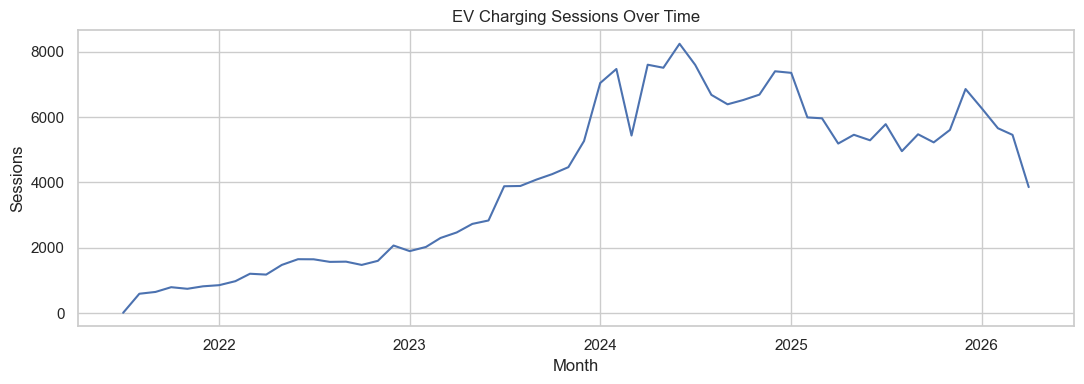

In [42]:
raw_for_plot = standardize_columns(raw)
if {'date', 'connected_time'}.issubset(raw_for_plot.columns):
    raw_for_plot = parse_session_timestamps(raw_for_plot)
    monthly_sessions = raw_for_plot.dropna(subset=['session_start']).set_index('session_start').resample('MS').size().rename('sessions').reset_index()
    fig, ax = plt.subplots(figsize=(11, 4))
    sns.lineplot(data=monthly_sessions, x='session_start', y='sessions', ax=ax)
    ax.set_title('EV Charging Sessions Over Time')
    ax.set_xlabel('Month')
    ax.set_ylabel('Sessions')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'sessions_over_time.png', dpi=160)
    plt.show()


## 2. Data Cleaning and Session Validation
Invalid, incomplete, and physically implausible charging sessions are removed. Timestamps are parsed, station/location identifiers are standardized, valid overnight sessions are retained, and the cleaned session table is prepared for station-hour aggregation.


In [43]:
sessions, cleaning_report = clean_sessions(raw)
cleaning_summary = pd.DataFrame(list(cleaning_report.items()), columns=['Metric', 'Value'])
print('Table 1. Data Cleaning Summary')
display(cleaning_summary)
print(f"Session time range: {sessions['session_start'].min()} to {sessions['session_start'].max()}")
display(sessions[['session_start', 'session_end', 'station_name', 'location_name', 'energy_provided_kwh', 'charge_duration_min']].head())


Table 1. Data Cleaning Summary


,Metric,Value
0,input_rows,236019
1,duplicates_removed,0
2,missing_removed,29
3,invalid_physical_sessions_removed,2056
4,overnight_sessions,31637
5,overnight_session_fraction,0.135239
6,clean_rows,233934
7,session_start_min,2021-07-31 09:58:31
8,session_start_max,2026-04-30 03:54:38


Session time range: 2021-07-31 09:58:31 to 2026-04-30 03:54:38


,session_start,session_end,station_name,location_name,energy_provided_kwh,charge_duration_min
0,2021-07-31 09:58:31,2021-07-31 11:25:40,EVB0415,Jerome 190th Street Municipal Parking,9.301,87.150000
1,2021-07-31 10:25:35,2021-07-31 20:40:03,NYCDOT DE3,Delancey and Essex Municipal Parking Garage,22.547,230.021233
2,2021-07-31 12:02:16,2021-07-31 15:08:23,EVB0415,Jerome 190th Street Municipal Parking,10.357,135.416667
3,2021-07-31 13:28:25,2021-08-01 05:17:19,NYC19,Bay Ridge Municipal Parking Garage,31.333,325.046233
4,2021-07-31 19:12:43,2021-07-31 21:45:13,EVB0301,Delancey and Essex Municipal Parking Garage,16.251,152.500000


## 3. Station-Hour Forecasting Target Construction
The cleaned session-level data is converted into a regular station-hour panel. For each station and hour, the notebook computes two targets: active charging demand (`session_count`) and hourly energy consumption (`total_energy_kwh`).


In [44]:
demand = build_station_hour_demand(sessions)
target_key_cols = [*SERIES_KEYS, 'hour_ts']
duplicate_station_hours = demand.duplicated(target_key_cols).sum()
assert duplicate_station_hours == 0, 'Demand table has duplicate station-hour rows.'

target_summary = pd.DataFrame({
    'metric': [
        'station_hour_rows', 'stations', 'locations', 'hours', 'time_start', 'time_end',
        'session_zero_fraction', 'energy_zero_fraction', 'total_active_sessions', 'total_energy_kwh'
    ],
    'value': [
        len(demand),
        demand['station_name'].nunique(),
        demand['location_name'].nunique(),
        demand['hour_ts'].nunique(),
        str(demand['hour_ts'].min()),
        str(demand['hour_ts'].max()),
        float((demand[TARGET] == 0).mean()),
        float((demand[ENERGY_TARGET] == 0).mean()),
        float(demand[TARGET].sum()),
        float(demand[ENERGY_TARGET].sum()),
    ],
})
display(target_summary)


,metric,value
0,station_hour_rows,2469125
1,stations,132
2,locations,21
3,hours,41391
4,time_start,2021-07-31 09:00:00
5,time_end,2026-04-30 04:00:00
6,session_zero_fraction,0.638602
7,energy_zero_fraction,0.638603
8,total_active_sessions,1003796.0
9,total_energy_kwh,5367714.937


## 4. Exploratory Target Analysis
This section examines the station-hour targets before modeling. The plots show demand sparsity, energy skewness, hourly and weekly usage patterns, and why temporal features such as lags, rolling windows, and station history are necessary.


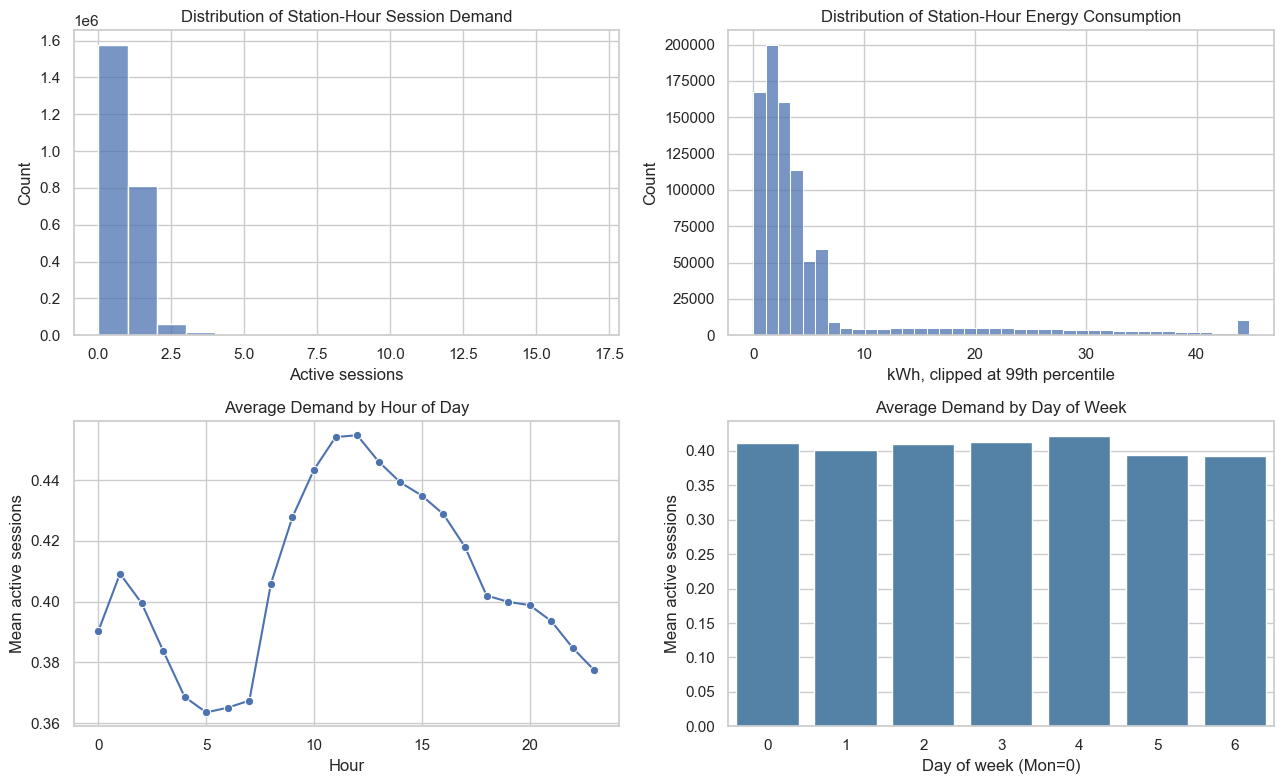

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(demand[TARGET], bins=range(0, int(demand[TARGET].max()) + 2), ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Station-Hour Session Demand')
axes[0, 0].set_xlabel('Active sessions')

positive_energy = demand.loc[demand[ENERGY_TARGET] > 0, ENERGY_TARGET]
sns.histplot(positive_energy.clip(upper=positive_energy.quantile(0.99)), bins=40, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Station-Hour Energy Consumption')
axes[0, 1].set_xlabel('kWh, clipped at 99th percentile')

hourly_pattern = demand.assign(hour=demand['hour_ts'].dt.hour).groupby('hour', as_index=False)[TARGET].mean()
sns.lineplot(data=hourly_pattern, x='hour', y=TARGET, marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Average Demand by Hour of Day')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Mean active sessions')

weekday_pattern = demand.assign(day_of_week=demand['hour_ts'].dt.dayofweek).groupby('day_of_week', as_index=False)[TARGET].mean()
sns.barplot(data=weekday_pattern, x='day_of_week', y=TARGET, ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Average Demand by Day of Week')
axes[1, 1].set_xlabel('Day of week (Mon=0)')
axes[1, 1].set_ylabel('Mean active sessions')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'target_analysis_figures.png', dpi=160)
plt.show()


## 5. Temporal and Station-Level Feature Engineering
Lag, rolling-window, exponentially weighted, calendar, and station-level historical features are created to capture short-term persistence, daily cycles, weekly seasonality, and station-specific demand behavior.


In [46]:
feature_df = add_better_lag_features(demand)

calendar_numeric_features = [
    'hour', 'day_of_week', 'month', 'quarter', 'season', 'is_weekend', 'is_holiday',
    'is_holiday_or_weekend', 'is_peak_hour', 'hour_sin', 'hour_cos', 'dow_sin',
    'dow_cos', 'month_sin', 'month_cos',
]
engineered_numeric_features = [
    col for col in feature_df.columns
    if col not in CATEGORICAL_FEATURES and col.startswith(('lag_', 'rolling_', 'station_', 'global_', 'energy_'))
]
all_candidate_numeric_features = calendar_numeric_features + sorted(
    col for col in engineered_numeric_features if col not in calendar_numeric_features
)

feature_group_summary = pd.DataFrame([
    {'Feature Group': 'Calendar features', 'Examples': 'hour, day_of_week, month, weekend', 'Purpose': 'capture temporal cycles'},
    {'Feature Group': 'Lag features', 'Examples': 'lag_1h, lag_24h, lag_168h', 'Purpose': 'capture recent/daily/weekly persistence'},
    {'Feature Group': 'Rolling features', 'Examples': 'rolling_6h, rolling_24h, rolling_168h', 'Purpose': 'capture local trends'},
    {'Feature Group': 'Station history', 'Examples': 'station_hour_mean, station_dow_hour_mean', 'Purpose': 'capture station-specific behavior'},
    {'Feature Group': 'Energy history', 'Examples': 'energy_lag_1h, energy_rolling_3h', 'Purpose': 'support energy forecasting'},
])
display(feature_group_summary)

required_history_lag = 'lag_168h_sessions' if feature_df['lag_168h_sessions'].notna().any() else 'lag_24h_sessions'
model_df = feature_df.dropna(subset=[required_history_lag, *CATEGORICAL_FEATURES, TARGET]).reset_index(drop=True)
print(f'Required history lag: {required_history_lag}')
print(f'Candidate numeric features: {len(all_candidate_numeric_features):,}')
print(f'Rows after lag drop: {len(model_df):,}')


,Feature Group,Examples,Purpose
0,Calendar features,"hour, day_of_week, month, weekend",capture temporal cycles
1,Lag features,"lag_1h, lag_24h, lag_168h",capture recent/daily/weekly persistence
2,Rolling features,"rolling_6h, rolling_24h, rolling_168h",capture local trends
3,Station history,"station_hour_mean, station_dow_hour_mean",capture station-specific behavior
4,Energy history,"energy_lag_1h, energy_rolling_3h",support energy forecasting


Required history lag: lag_168h_sessions
Candidate numeric features: 179
Rows after lag drop: 2,432,113


### EDA Graph: Demand Heatmap by Day and Hour
This heatmap shows how average active charging sessions vary by day of week and hour of day. It motivates calendar variables, peak-hour indicators, daily lags, and weekly lags.


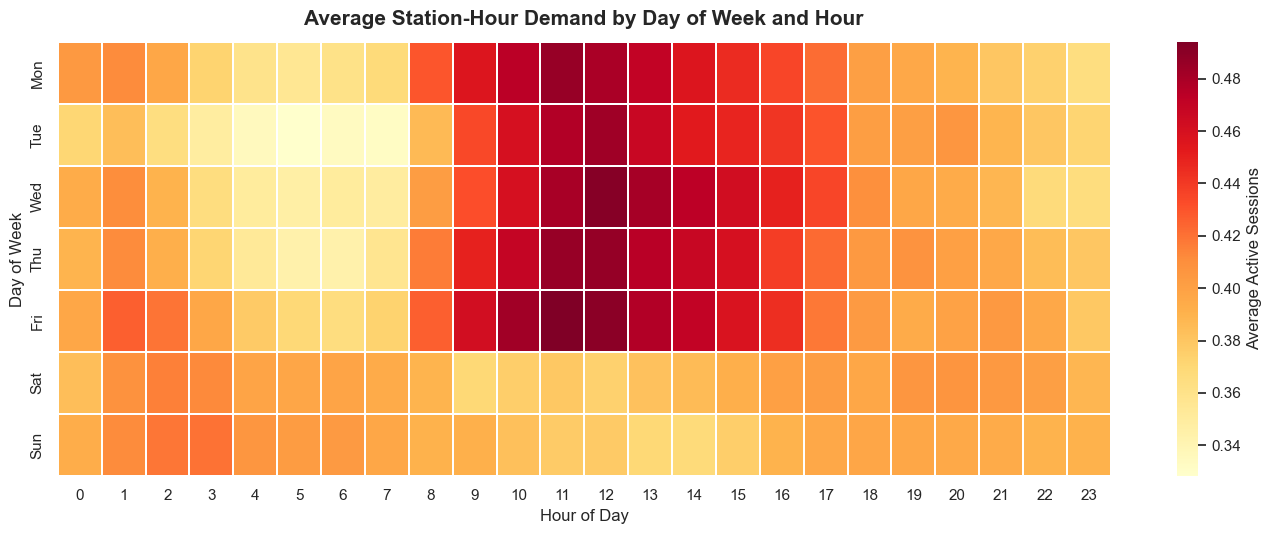

In [75]:

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

demand_heatmap_df = feature_df.copy()

if "day_name" not in demand_heatmap_df.columns:
    demand_heatmap_df["day_name"] = demand_heatmap_df["hour_ts"].dt.day_name().str[:3]

demand_heatmap = (
    demand_heatmap_df
    .groupby(["day_name", "hour"], as_index=False)[TARGET]
    .mean()
)

demand_heatmap_pivot = (
    demand_heatmap
    .pivot(index="day_name", columns="hour", values=TARGET)
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(14, 5.5))

sns.heatmap(
    demand_heatmap_pivot,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Average Active Sessions"},
    ax=ax
)

ax.set_title(
    "Average Station-Hour Demand by Day of Week and Hour",
    fontsize=15,
    weight="bold",
    pad=12
)
ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Day of Week", fontsize=12)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "eda_demand_heatmap_day_hour.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

### EDA Graph: Energy Heatmap by Day and Hour
This heatmap shows how average station-hour kWh varies by day and hour. It helps compare energy patterns with demand patterns and supports the need for energy-history and intensity features.


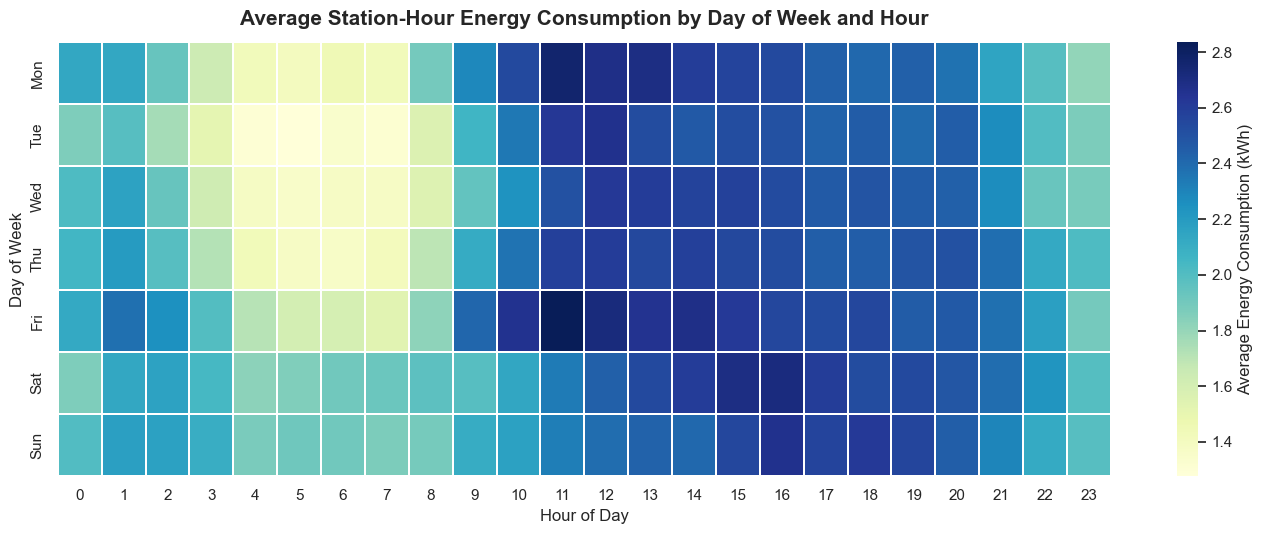

In [76]:
# ============================================================
# EDA Graph 2: Average Station-Hour Energy by Day and Hour
# ============================================================

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

energy_heatmap_df = feature_df.copy()

if "day_name" not in energy_heatmap_df.columns:
    energy_heatmap_df["day_name"] = energy_heatmap_df["hour_ts"].dt.day_name().str[:3]

energy_heatmap = (
    energy_heatmap_df
    .groupby(["day_name", "hour"], as_index=False)[ENERGY_TARGET]
    .mean()
)

energy_heatmap_pivot = (
    energy_heatmap
    .pivot(index="day_name", columns="hour", values=ENERGY_TARGET)
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(14, 5.5))

sns.heatmap(
    energy_heatmap_pivot,
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Average Energy Consumption (kWh)"},
    ax=ax
)

ax.set_title(
    "Average Station-Hour Energy Consumption by Day of Week and Hour",
    fontsize=15,
    weight="bold",
    pad=12
)
ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Day of Week", fontsize=12)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "eda_energy_heatmap_day_hour.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

### EDA Graph: Demand Volume vs. Energy Consumption
This plot compares active sessions with total station-hour kWh. It shows that energy generally increases with demand, but the relationship is noisy because charging intensity, duration, and user behavior vary.


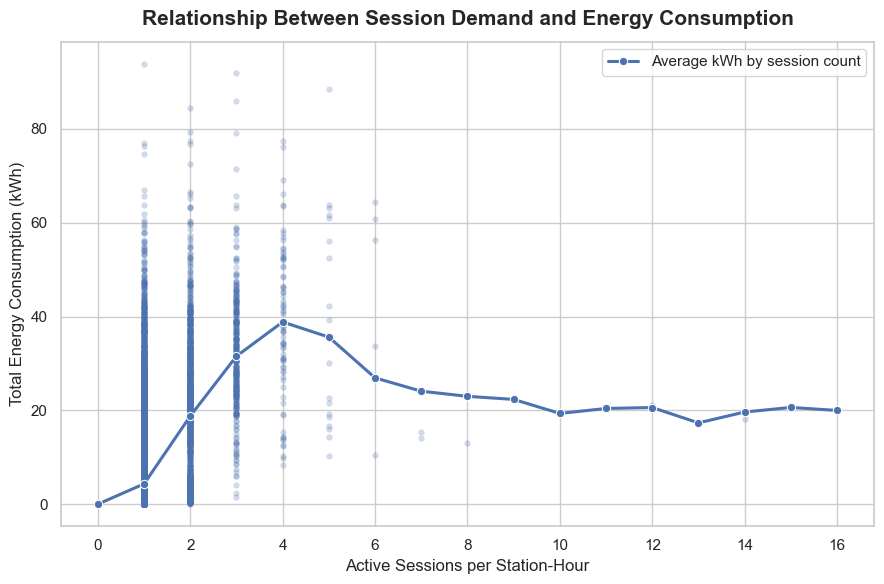

In [77]:
# ============================================================
# EDA Graph 3: Relationship Between Demand and Energy
# ============================================================

scatter_df = feature_df[[TARGET, ENERGY_TARGET]].dropna().copy()

# Sampling keeps the plot readable and fast
sample_n = min(50000, len(scatter_df))
scatter_sample = scatter_df.sample(sample_n, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=scatter_sample,
    x=TARGET,
    y=ENERGY_TARGET,
    alpha=0.25,
    s=16,
    edgecolor=None,
    ax=ax
)

# Add mean energy by session count line for easier interpretation
mean_line = (
    scatter_df
    .groupby(TARGET, as_index=False)[ENERGY_TARGET]
    .mean()
    .sort_values(TARGET)
)

sns.lineplot(
    data=mean_line,
    x=TARGET,
    y=ENERGY_TARGET,
    marker="o",
    linewidth=2.2,
    ax=ax,
    label="Average kWh by session count"
)

ax.set_title(
    "Relationship Between Session Demand and Energy Consumption",
    fontsize=15,
    weight="bold",
    pad=12
)
ax.set_xlabel("Active Sessions per Station-Hour", fontsize=12)
ax.set_ylabel("Total Energy Consumption (kWh)", fontsize=12)
ax.legend(title="")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "eda_demand_vs_energy_scatter.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

### Feature Validation: Lag Correlation with Future Demand
This diagnostic ranks lag and rolling features by their correlation with station-hour demand. It provides evidence that recent, daily, and weekly history contain useful predictive signal.


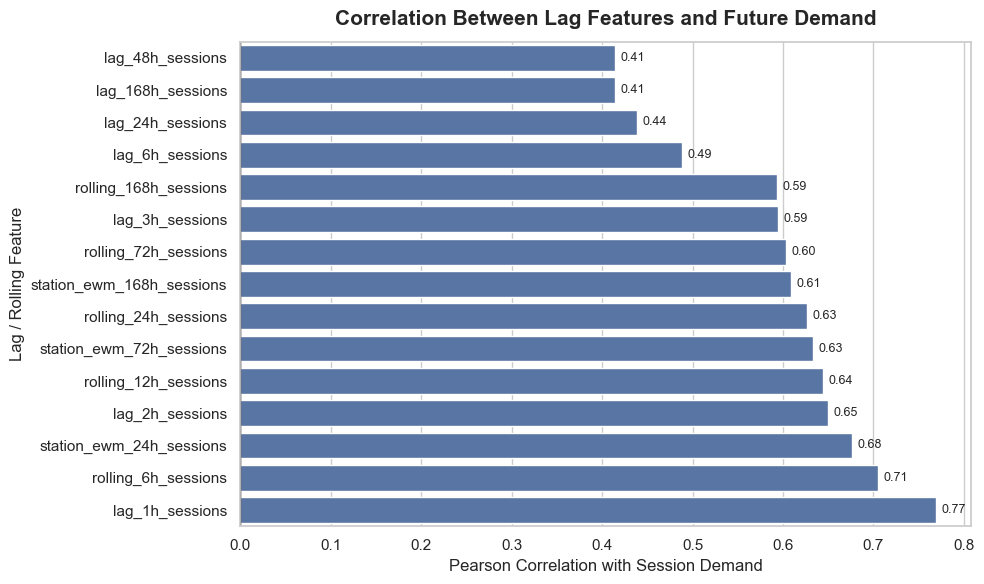

,feature,correlation,abs_correlation
0,lag_1h_sessions,0.769482,0.769482
12,rolling_6h_sessions,0.705025,0.705025
17,station_ewm_24h_sessions,0.676519,0.676519
1,lag_2h_sessions,0.650062,0.650062
13,rolling_12h_sessions,0.644723,0.644723
18,station_ewm_72h_sessions,0.633715,0.633715
14,rolling_24h_sessions,0.626970,0.626970
19,station_ewm_168h_sessions,0.608827,0.608827
15,rolling_72h_sessions,0.602931,0.602931
2,lag_3h_sessions,0.594903,0.594903


In [78]:
# ============================================================
# Feature Engineering Graph 1: Lag Feature Correlation with Future Demand
# ============================================================

# Candidate demand-related lag/rolling/EWM features
candidate_lag_features = [
    "lag_1h_sessions",
    "lag_2h_sessions",
    "lag_3h_sessions",
    "lag_6h_sessions",
    "lag_12h_sessions",
    "lag_24h_sessions",
    "lag_48h_sessions",
    "lag_72h_sessions",
    "lag_167h_sessions",
    "lag_168h_sessions",
    "lag_169h_sessions",
    "lag_336h_sessions",
    "rolling_6h_sessions",
    "rolling_12h_sessions",
    "rolling_24h_sessions",
    "rolling_72h_sessions",
    "rolling_168h_sessions",
    "station_ewm_24h_sessions",
    "station_ewm_72h_sessions",
    "station_ewm_168h_sessions",
    "global_lag_1h_sessions",
    "global_lag_24h_sessions",
    "global_lag_168h_sessions",
]

available_lag_features = [
    col for col in candidate_lag_features
    if col in feature_df.columns
]

corr_rows = []

for col in available_lag_features:
    tmp = feature_df[[TARGET, col]].replace([np.inf, -np.inf], np.nan).dropna()

    if len(tmp) > 10 and tmp[col].nunique() > 1:
        corr_rows.append({
            "feature": col,
            "correlation": tmp[TARGET].corr(tmp[col])
        })

lag_corr_df = (
    pd.DataFrame(corr_rows)
    .dropna()
    .assign(abs_correlation=lambda d: d["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
)

lag_corr_df.to_csv(
    OUTPUT_DIR / "lag_feature_correlation_with_demand.csv",
    index=False
)

plot_lag_corr = lag_corr_df.head(15).sort_values("correlation")

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_lag_corr,
    x="correlation",
    y="feature",
    ax=ax
)

ax.axvline(0, color="black", linewidth=1)

ax.set_title(
    "Correlation Between Lag Features and Future Demand",
    fontsize=15,
    weight="bold",
    pad=12
)
ax.set_xlabel("Pearson Correlation with Session Demand", fontsize=12)
ax.set_ylabel("Lag / Rolling Feature", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=4, fontsize=9)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "feature_engineering_lag_correlation_demand.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

display(lag_corr_df.head(15))

### Feature Group Summary Placeholder
The final feature-group summary is generated later after both demand and energy feature sets are finalized. This avoids counting incomplete feature groups before the energy-model features are created.


## 6. Temporal Train-Test Split and Feature Selection
A chronological split is used so the model is trained on earlier data and evaluated on later data. The section also audits engineered features, selects the strongest numeric predictors, and validates lag alignment to prevent leakage.


In [47]:
train_df, test_df, cutoff = temporal_train_test_split(model_df, test_size=0.2)
audited_numeric_features, feature_audit = audit_numeric_features(train_df, all_candidate_numeric_features)
base_numeric_features, feature_selection = select_top_numeric_features(
    train_df,
    audited_numeric_features,
    CATEGORICAL_FEATURES,
    max_features=MAX_SELECTED_NUMERIC_FEATURES,
)
lag_alignment_audit = validate_lag_alignment(feature_df, lag=168)

feature_audit.to_csv(OUTPUT_DIR / 'lag_feature_audit.csv', index=False)
feature_selection.to_csv(OUTPUT_DIR / 'feature_selection_importance.csv', index=False)
lag_alignment_audit.to_csv(OUTPUT_DIR / 'lag_alignment_audit.csv', index=False)

split_summary = pd.DataFrame([
    time_range_summary('all_model_rows', model_df),
    time_range_summary('train', train_df),
    time_range_summary('test', test_df),
])
print(f'Temporal cutoff: train rows are before {cutoff}; test rows are at/after {cutoff}')
print(f'Selected numeric features: {len(base_numeric_features):,} / {len(audited_numeric_features):,}')
display(split_summary)
display(lag_alignment_audit)

unselected_positive_features = feature_selection[(~feature_selection['selected']) & (feature_selection['importance_mean'] > 0)]
print(f'Positive-importance features not selected: {len(unselected_positive_features):,}')
display(feature_selection.head(20))


Temporal cutoff: train rows are before 2025-05-23 02:00:00; test rows are at/after 2025-05-23 02:00:00
Selected numeric features: 100 / 179


,name,rows,hours,stations,start,end,target_mean,target_zero_fraction
0,all_model_rows,2432113,41055,130,2021-08-07 09:00:00,2026-04-30 04:00:00,0.406743,0.638306
1,train,1829414,32844,118,2021-08-07 09:00:00,2025-05-23 01:00:00,0.403725,0.636639
2,test,602699,8211,92,2025-05-23 02:00:00,2026-04-30 04:00:00,0.415904,0.643366


,lag,checked_rows,aligned_fraction,max_abs_value_difference,status
0,168,2432113,1.0,0.0,ok


Positive-importance features not selected: 11


,feature,importance_mean,importance_std,family,selected
0,energy_lag_1h,0.149621,0.004995,energy_history,True
1,station_ewm_24h_sessions,0.063151,0.006305,ewm,True
2,energy_rolling_3h_mean,0.055342,0.002856,energy_history,True
3,lag_1h_to_24h_ratio,0.035020,0.002055,momentum_ratio,True
4,energy_rolling_6h_mean,0.034058,0.002727,energy_history,True
5,energy_recent_trend_1h_3h,0.023256,0.001157,energy_history,True
6,energy_lag_2h,0.017482,0.001226,energy_history,True
7,rolling_168h_occupancy,0.015724,0.002405,load_intensity,True
8,energy_rolling_12h_mean,0.010886,0.001217,energy_history,True
9,energy_rolling_3h_std,0.007194,0.000598,rolling_stat,True


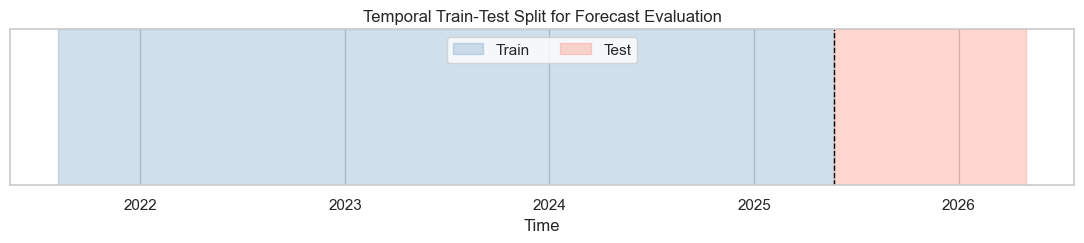

In [48]:
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.axvspan(train_df['hour_ts'].min(), train_df['hour_ts'].max(), color='steelblue', alpha=0.25, label='Train')
ax.axvspan(test_df['hour_ts'].min(), test_df['hour_ts'].max(), color='tomato', alpha=0.25, label='Test')
ax.axvline(cutoff, color='black', linestyle='--', linewidth=1)
ax.set_title('Temporal Train-Test Split for Forecast Evaluation')
ax.set_xlabel('Time')
ax.set_yticks([])
ax.legend(loc='upper center', ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'temporal_train_test_split.png', dpi=160)
plt.show()


## 7. Demand Forecasting Model
### Goal: Predict Active Charging Sessions per Station-Hour
The demand model predicts the number of vehicles actively charging at each station during each future hour. The task is sparse and zero-heavy, so temporal baselines and machine-learning models are compared on a future holdout period.


In [49]:
demand_full_comparison, demand_model_table, demand_best_model, demand_best_pred, demand_all_predictions = compare_models(
    train_df,
    test_df,
    base_numeric_features,
    CATEGORICAL_FEATURES,
    target_col=TARGET,
    objective='count',
    keep_models=['Ridge_L2', 'Lasso_L1', 'LightGBM_squared', 'HistGradientBoosting_squared_tuned'],
)

demand_keep = [
    'Baseline_lag_1h_sessions',
    'Baseline_blend_recent_daily_weekly',
    'Ridge_L2',
    'Lasso_L1',
    'HistGradientBoosting_squared_tuned',
    'LightGBM_squared',
    'Blend_top_demand_models',
]
demand_results = compact_performance_table(demand_full_comparison, demand_keep)
demand_full_comparison.to_csv(OUTPUT_DIR / 'demand_all_model_comparison.csv', index=False)
demand_results.to_csv(OUTPUT_DIR / 'demand_model_performance_table.csv', index=False)
print('Table 2. Demand Forecasting Model Performance on Future Test Set')
display(demand_results)
print(f"Selected demand model: {demand_model_table.iloc[0]['Model']}")



Baseline done: Baseline_lag_1h_sessions | MAE=0.1303 | RMSE=0.4160 | R2=0.5667
Baseline done: Baseline_lag_24h_sessions | MAE=0.3235 | RMSE=0.6415 | R2=-0.0302
Baseline done: Baseline_lag_168h_sessions | MAE=0.3369 | RMSE=0.6582 | R2=-0.0847
Baseline done: Baseline_blend_recent_daily_weekly | MAE=0.2466 | RMSE=0.4409 | R2=0.5133
Model done: Ridge_L2 | CV_R2=0.6365 | Test MAE=0.1747 | Test RMSE=0.3597 | Test R2=0.6762 | seconds=101.7
Model done: Lasso_L1 | CV_R2=0.6359 | Test MAE=0.1766 | Test RMSE=0.3604 | Test R2=0.6748 | seconds=392.7
Model done: HistGradientBoosting_squared_tuned | CV_R2=0.6940 | Test MAE=0.1417 | Test RMSE=0.3291 | Test R2=0.7288 | seconds=387.4
Model done: LightGBM_squared | CV_R2=0.6940 | Test MAE=0.1399 | Test RMSE=0.3280 | Test R2=0.7306 | seconds=204.2
Blend done: Blend_top_demand_models | Test MAE=0.1406 | Test RMSE=0.3280 | Test R2=0.7307
Table 2. Demand Forecasting Model Performance on Future Test Set


,Model,MAE,RMSE,R²,WMAPE (%)
0,Baseline_lag_1h_sessions,0.130257,0.416047,0.566664,31.319091
1,Baseline_blend_recent_daily_weekly,0.246639,0.440902,0.513341,59.301857
2,Ridge_L2,0.174653,0.359655,0.676174,41.993544
3,Lasso_L1,0.176625,0.360403,0.674825,42.467793
4,HistGradientBoosting_squared_tuned,0.141688,0.329145,0.728785,34.067543
5,LightGBM_squared,0.139862,0.328026,0.730625,33.628312
6,Blend_top_demand_models,0.140586,0.327995,0.730675,33.802412


Selected demand model: Blend_top_demand_models


## 8. Demand Model Evaluation and Interpretation
This section evaluates demand predictions using station-hour scatter plots, system-wide time-series diagnostics, station-level metrics, and feature importance. The goal is to understand both predictive accuracy and operational usefulness.


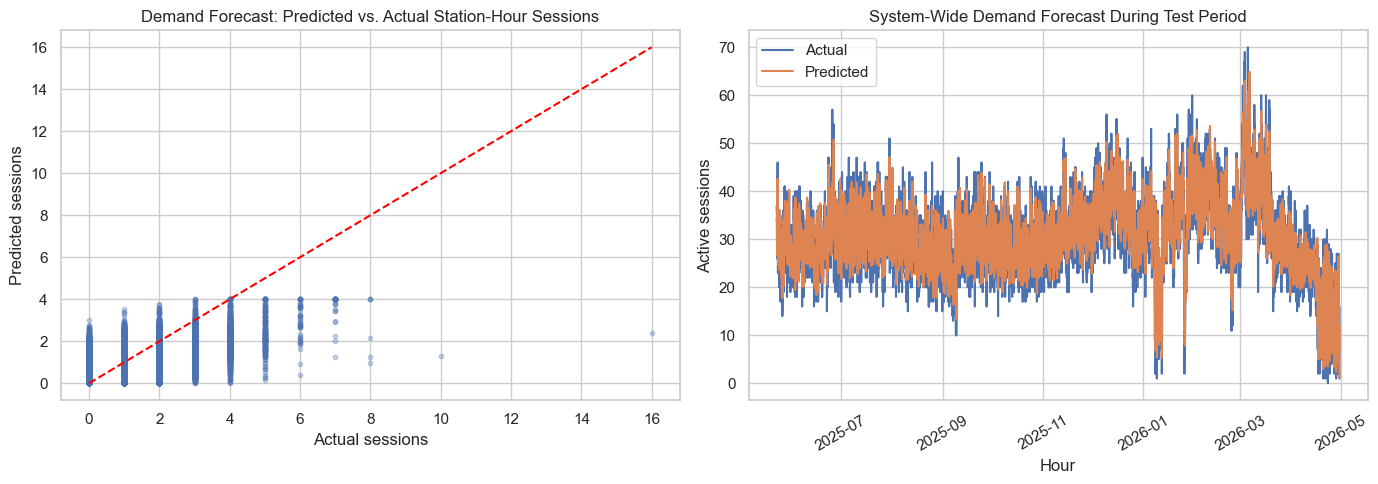

,station_name,location_name,rows,actual_total,predicted_total,MAE,RMSE,MAPE_nonzero_pct,WMAPE_pct,R2
0,BTCE00,QBO - Queens Borough Hall Municipal Parking Ga...,1422,2975.0,2949.818573,0.847319,1.101040,42.474044,40.500418,0.572974
1,EV0444,CSQ - Court Square Municipal Parking Garage,8192,8863.0,9082.607875,0.633425,0.882078,43.351754,58.546979,0.419609
2,101337,QBO - Queens Borough Hall Municipal Parking Ga...,8211,10841.0,10943.581851,0.630332,0.853569,40.401400,47.741534,0.436668
3,101336,QBO - Queens Borough Hall Municipal Parking Ga...,8209,8446.0,8478.516184,0.515036,0.779784,41.005470,50.058363,0.557489
4,101338,QBO - Queens Borough Hall Municipal Parking Ga...,8209,7813.0,8113.190139,0.568330,0.742844,39.383820,59.713612,0.439158
5,EV0436,CSQ - Court Square Municipal Parking Garage,8210,8134.0,8418.544638,0.583025,0.736289,38.422457,58.847277,0.330835
6,EV0445,DES - Delancey and Essex Municipal Parking Garage,8209,5571.0,5531.534963,0.473556,0.717909,41.693915,69.779584,0.428283
7,EV0156,CSQ - Court Square Municipal Parking Garage,1563,1157.0,1197.858475,0.533624,0.695789,38.605913,72.087636,0.294493
8,EV0437,CSQ - Court Square Municipal Parking Garage,8209,6601.0,6811.085325,0.523939,0.682375,39.798288,65.157011,0.411850
9,EV0449,DES - Delancey and Essex Municipal Parking Garage,8204,3574.0,3639.785920,0.398927,0.657669,47.088529,91.572273,0.346388


In [50]:
demand_predictions = test_df[['hour_ts', 'station_name', 'location_name', TARGET]].copy()
demand_predictions['predicted_session_count'] = demand_best_pred
demand_predictions.to_csv(OUTPUT_DIR / 'demand_test_predictions.csv', index=False)

demand_station_metrics = station_level_metrics(demand_predictions, TARGET, 'predicted_session_count')
demand_station_metrics.to_csv(OUTPUT_DIR / 'demand_station_level_metrics.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(demand_predictions[TARGET], demand_predictions['predicted_session_count'], alpha=0.3, s=10)
limit = max(demand_predictions[TARGET].max(), demand_predictions['predicted_session_count'].max())
axes[0].plot([0, limit], [0, limit], color='red', linestyle='--')
axes[0].set_title('Demand Forecast: Predicted vs. Actual Station-Hour Sessions')
axes[0].set_xlabel('Actual sessions')
axes[0].set_ylabel('Predicted sessions')

system_demand_eval = demand_predictions.groupby('hour_ts', as_index=False).agg(actual=(TARGET, 'sum'), predicted=('predicted_session_count', 'sum'))
sns.lineplot(data=system_demand_eval, x='hour_ts', y='actual', ax=axes[1], label='Actual')
sns.lineplot(data=system_demand_eval, x='hour_ts', y='predicted', ax=axes[1], label='Predicted')
axes[1].set_title('System-Wide Demand Forecast During Test Period')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Active sessions')
axes[1].tick_params(axis='x', rotation=30)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'demand_forecast_evaluation.png', dpi=160)
plt.show()

display(demand_station_metrics.head(10))


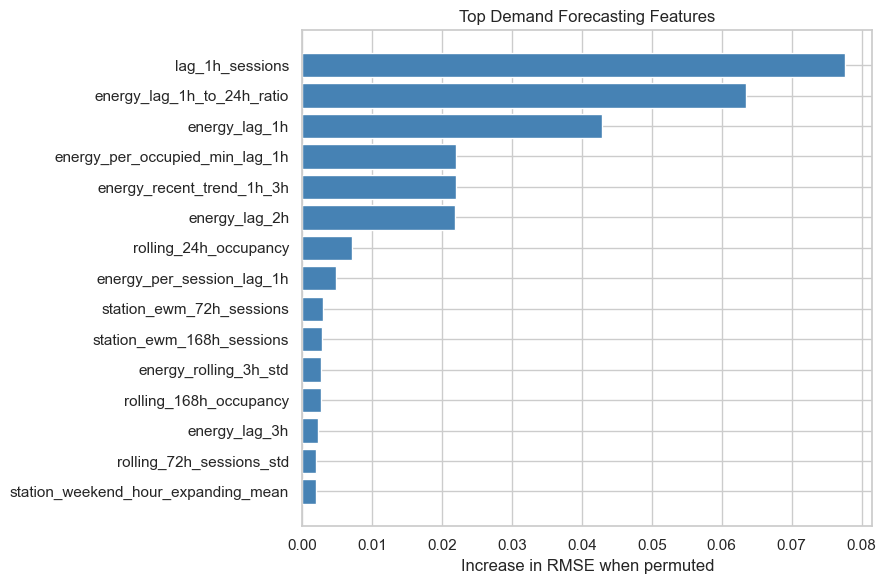

,feature,importance_mean,importance_std
0,lag_1h_sessions,0.077642,0.001242
1,energy_lag_1h_to_24h_ratio,0.063462,0.000893
2,energy_lag_1h,0.042867,0.001154
3,energy_per_occupied_min_lag_1h,0.021958,0.001381
4,energy_recent_trend_1h_3h,0.021904,0.002771
5,energy_lag_2h,0.021866,0.000396
6,rolling_24h_occupancy,0.007058,0.000765
7,energy_per_session_lag_1h,0.004832,0.000659
8,station_ewm_72h_sessions,0.002967,0.000144
9,station_ewm_168h_sessions,0.002804,0.000227


In [51]:
demand_importance = save_model_feature_importance(
    demand_best_model,
    test_df,
    base_numeric_features,
    CATEGORICAL_FEATURES,
    TARGET,
    OUTPUT_DIR / 'demand_feature_importance.csv',
    OUTPUT_DIR / 'demand_feature_importance.png',
    'Top Demand Forecasting Features',
)
display(demand_importance.head(15))


## 9. Energy Consumption Forecasting Model
### Goal: Predict Total kWh per Station-Hour
The energy model predicts hourly energy consumption for each station. This is harder than demand forecasting because kWh depends not only on the number of active sessions, but also on charging intensity, duration, vehicle limits, and user behavior.


In [52]:
energy_candidate_features = calendar_numeric_features + sorted(
    col for col in feature_df.columns
    if col not in CATEGORICAL_FEATURES
    and col.startswith(('energy_', 'global_energy_', 'station_energy_', 'lag_', 'rolling_', 'station_', 'global_'))
)
energy_required_history_lag = 'energy_lag_168h' if feature_df['energy_lag_168h'].notna().any() else 'energy_lag_24h'
energy_model_df = feature_df.dropna(subset=[energy_required_history_lag, *CATEGORICAL_FEATURES, ENERGY_TARGET]).reset_index(drop=True)
energy_train_df, energy_test_df, energy_cutoff = temporal_train_test_split(energy_model_df, test_size=0.2)
energy_audited_features, energy_feature_audit = audit_numeric_features(energy_train_df, energy_candidate_features)
energy_selected_features, energy_feature_selection = select_top_numeric_features(
    energy_train_df,
    energy_audited_features,
    CATEGORICAL_FEATURES,
    max_features=ENERGY_MAX_SELECTED_NUMERIC_FEATURES,
    target_col=ENERGY_TARGET,
)
energy_numeric_features = energy_audited_features if USE_ALL_AUDITED_ENERGY_FEATURES else energy_selected_features

# Add predicted session demand as a non-leaky proxy for target-time occupancy.
session_feature_cols = base_numeric_features + CATEGORICAL_FEATURES
energy_train_df = energy_train_df.copy()
energy_test_df = energy_test_df.copy()
energy_train_df['predicted_session_count_feature'] = np.maximum(0, demand_best_model.predict(energy_train_df[session_feature_cols]))
energy_test_df['predicted_session_count_feature'] = np.maximum(0, demand_best_model.predict(energy_test_df[session_feature_cols]))
energy_numeric_features = list(dict.fromkeys([*energy_numeric_features, 'predicted_session_count_feature']))

energy_full_comparison, energy_model_table, energy_best_model, energy_best_pred, energy_all_predictions = compare_models(
    energy_train_df,
    energy_test_df,
    energy_numeric_features,
    CATEGORICAL_FEATURES,
    target_col=ENERGY_TARGET,
    baseline_lag_col=energy_required_history_lag,
    objective='energy',
    keep_models=['Ridge_L2', 'Lasso_L1', 'HistGradientBoosting_squared_tuned', 'CatBoost_RMSE'],
)

energy_keep = [
    'Baseline_energy_lag_1h',
    'Baseline_blend_recent_daily_weekly',
    'Ridge_L2',
    'Lasso_L1',
    'HistGradientBoosting_squared_tuned',
    'CatBoost_RMSE',
]
energy_results = compact_performance_table(energy_full_comparison, energy_keep)
energy_full_comparison.to_csv(OUTPUT_DIR / 'energy_all_model_comparison.csv', index=False)
energy_results.to_csv(OUTPUT_DIR / 'energy_model_performance_table.csv', index=False)
print('Table 3. Energy Forecasting Model Performance on Future Test Set')
display(energy_results)
print(f"Selected energy model: {energy_model_table.iloc[0]['Model']}")



Baseline done: Baseline_energy_lag_1h | MAE=1.5443 | RMSE=6.0492 | R2=0.3351
Baseline done: Baseline_energy_lag_24h | MAE=2.6083 | RMSE=7.1106 | R2=0.0813
Baseline done: Baseline_energy_lag_168h | MAE=2.6990 | RMSE=7.3102 | R2=0.0290
Baseline done: Baseline_blend_recent_daily_weekly | MAE=1.9696 | RMSE=5.3913 | R2=0.4719
Baseline done: Baseline_forced_energy_lag_168h | MAE=2.6990 | RMSE=7.3102 | R2=0.0290
Model done: Ridge_L2 | CV_R2=0.5372 | Test MAE=1.6520 | Test RMSE=4.7459 | Test R2=0.5907 | seconds=189.2
Model done: Lasso_L1 | CV_R2=0.5372 | Test MAE=1.6514 | Test RMSE=4.7468 | Test R2=0.5906 | seconds=2331.1
Model done: HistGradientBoosting_squared_tuned | CV_R2=0.5710 | Test MAE=1.4203 | Test RMSE=4.6559 | Test R2=0.6061 | seconds=328.9
Model done: CatBoost_RMSE | CV_R2=0.5720 | Test MAE=1.4202 | Test RMSE=4.6436 | Test R2=0.6082 | seconds=290.4
Table 3. Energy Forecasting Model Performance on Future Test Set


,Model,MAE,RMSE,R²,WMAPE (%)
0,Baseline_energy_lag_1h,1.544339,6.049248,0.335108,58.902896
1,Baseline_blend_recent_daily_weekly,1.969590,5.391301,0.471877,75.122476
2,Ridge_L2,1.652042,4.745932,0.590748,63.010823
3,Lasso_L1,1.651350,4.746805,0.590597,62.984437
4,HistGradientBoosting_squared_tuned,1.420277,4.655853,0.606136,54.171037
5,CatBoost_RMSE,1.420239,4.643597,0.608207,54.169594


Selected energy model: CatBoost_RMSE


## 10. Energy Model Evaluation and Interpretation
This section evaluates station-hour kWh predictions, compares aggregate predicted and actual system-wide energy, computes station-level diagnostics, and visualizes the most important energy forecasting features.


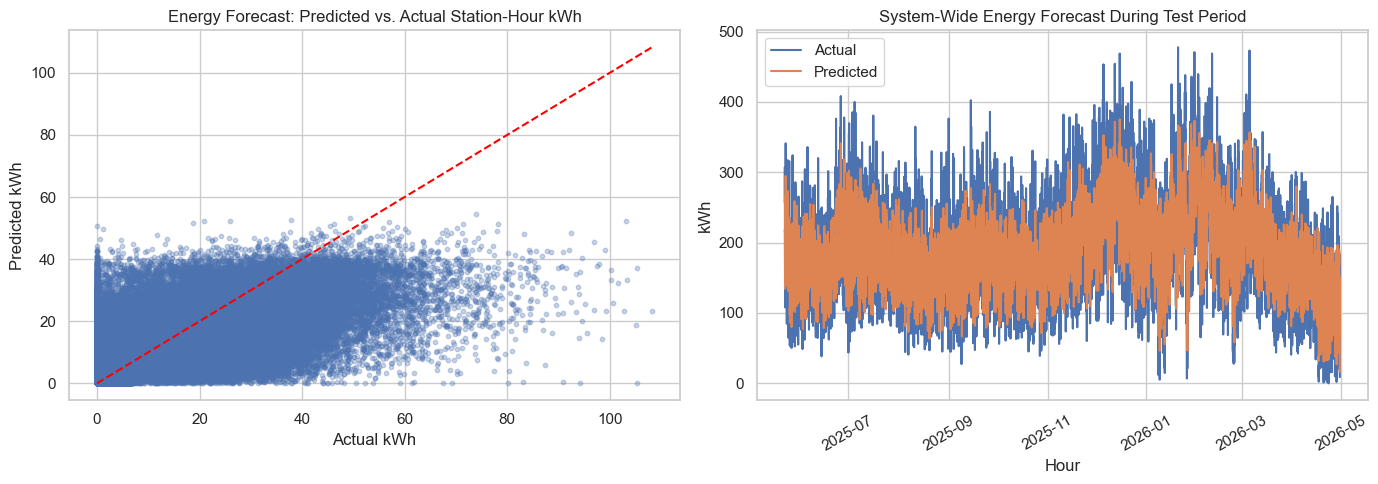

,station_name,location_name,rows,actual_total,predicted_total,MAE,RMSE,MAPE_nonzero_pct,WMAPE_pct,R2
0,EV0444,CSQ - Court Square Municipal Parking Garage,8192,159583.494000,143906.057610,12.807944,17.911320,206.055938,65.747827,0.360042
1,EV0445,DES - Delancey and Essex Municipal Parking Garage,8209,94998.321000,90530.013626,9.471329,14.785840,240.373633,81.843698,0.329192
2,101337,QBO - Queens Borough Hall Municipal Parking Ga...,8211,169161.835167,170350.112654,10.684729,14.136874,174.972158,51.862946,0.387587
3,101336,QBO - Queens Borough Hall Municipal Parking Ga...,8209,130052.735000,130998.425126,8.946903,13.255504,200.125160,56.473346,0.495321
4,101338,QBO - Queens Borough Hall Municipal Parking Ga...,8209,115789.847000,117682.170199,9.258332,11.972135,290.047269,65.637573,0.387373
5,EV0436,CSQ - Court Square Municipal Parking Garage,8210,114568.972000,114050.665643,9.463957,11.944265,144.149961,67.818612,0.276578
6,EV0156,CSQ - Court Square Municipal Parking Garage,1563,17589.318531,16860.065602,9.150844,11.816467,260.530500,81.315080,0.279026
7,EV0437,CSQ - Court Square Municipal Parking Garage,8209,97348.398000,94486.547397,8.704086,11.471504,176.482729,73.398068,0.350094
8,EV0448,DES - Delancey and Essex Municipal Parking Garage,8203,49122.505000,50659.619690,5.915076,8.780088,198.325733,98.776242,0.310732
9,EV0449,DES - Delancey and Essex Municipal Parking Garage,8204,36524.576000,38278.094277,4.510264,7.367987,195.502162,101.307698,0.294381


In [53]:
energy_predictions = energy_test_df[['hour_ts', 'station_name', 'location_name', ENERGY_TARGET]].copy()
energy_predictions['predicted_total_energy_kwh'] = energy_best_pred
energy_predictions.to_csv(OUTPUT_DIR / 'energy_test_predictions.csv', index=False)

energy_station_metrics = station_level_metrics(energy_predictions, ENERGY_TARGET, 'predicted_total_energy_kwh')
energy_station_metrics.to_csv(OUTPUT_DIR / 'energy_station_level_metrics.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(energy_predictions[ENERGY_TARGET], energy_predictions['predicted_total_energy_kwh'], alpha=0.3, s=10)
energy_limit = max(energy_predictions[ENERGY_TARGET].max(), energy_predictions['predicted_total_energy_kwh'].max())
axes[0].plot([0, energy_limit], [0, energy_limit], color='red', linestyle='--')
axes[0].set_title('Energy Forecast: Predicted vs. Actual Station-Hour kWh')
axes[0].set_xlabel('Actual kWh')
axes[0].set_ylabel('Predicted kWh')

system_energy_eval = energy_predictions.groupby('hour_ts', as_index=False).agg(actual=(ENERGY_TARGET, 'sum'), predicted=('predicted_total_energy_kwh', 'sum'))
sns.lineplot(data=system_energy_eval, x='hour_ts', y='actual', ax=axes[1], label='Actual')
sns.lineplot(data=system_energy_eval, x='hour_ts', y='predicted', ax=axes[1], label='Predicted')
axes[1].set_title('System-Wide Energy Forecast During Test Period')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('kWh')
axes[1].tick_params(axis='x', rotation=30)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'energy_forecast_evaluation.png', dpi=160)
plt.show()

display(energy_station_metrics.head(10))


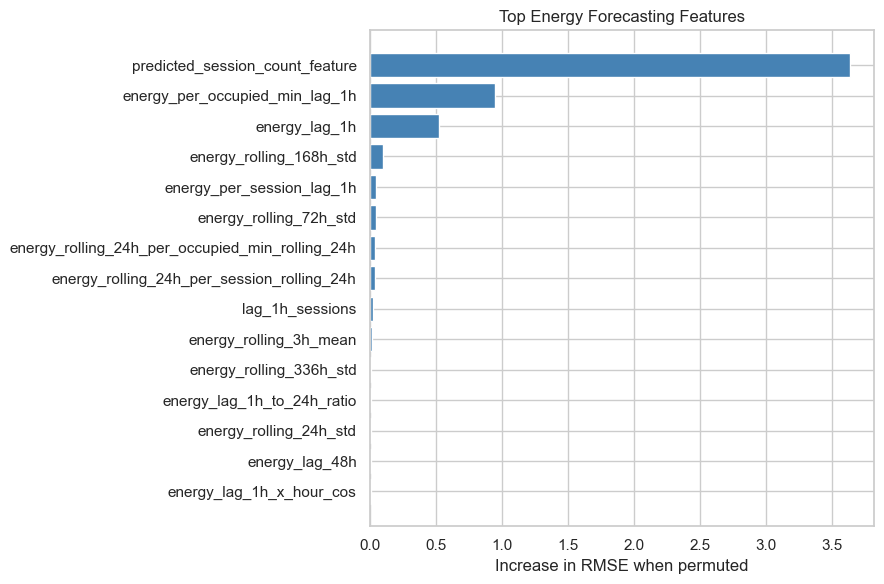

,feature,importance_mean,importance_std
0,predicted_session_count_feature,3.636794,0.017610
1,energy_per_occupied_min_lag_1h,0.950737,0.067367
2,energy_lag_1h,0.524033,0.026069
3,energy_rolling_168h_std,0.101249,0.002173
4,energy_per_session_lag_1h,0.049493,0.006218
5,energy_rolling_72h_std,0.047960,0.002659
6,energy_rolling_24h_per_occupied_min_rolling_24h,0.038207,0.004288
7,energy_rolling_24h_per_session_rolling_24h,0.036405,0.001984
8,lag_1h_sessions,0.024503,0.001447
9,energy_rolling_3h_mean,0.013806,0.004248


In [54]:
energy_importance = save_model_feature_importance(
    energy_best_model,
    energy_test_df,
    energy_numeric_features,
    CATEGORICAL_FEATURES,
    ENERGY_TARGET,
    OUTPUT_DIR / 'energy_feature_importance.csv',
    OUTPUT_DIR / 'energy_feature_importance.png',
    'Top Energy Forecasting Features',
)
display(energy_importance.head(15))


## 11. Cross-Task Feature Group Summary
After both demand and energy feature sets are finalized, this section groups the selected predictors into interpretable categories such as calendar, lag, rolling, station-history, energy-intensity, and categorical features.


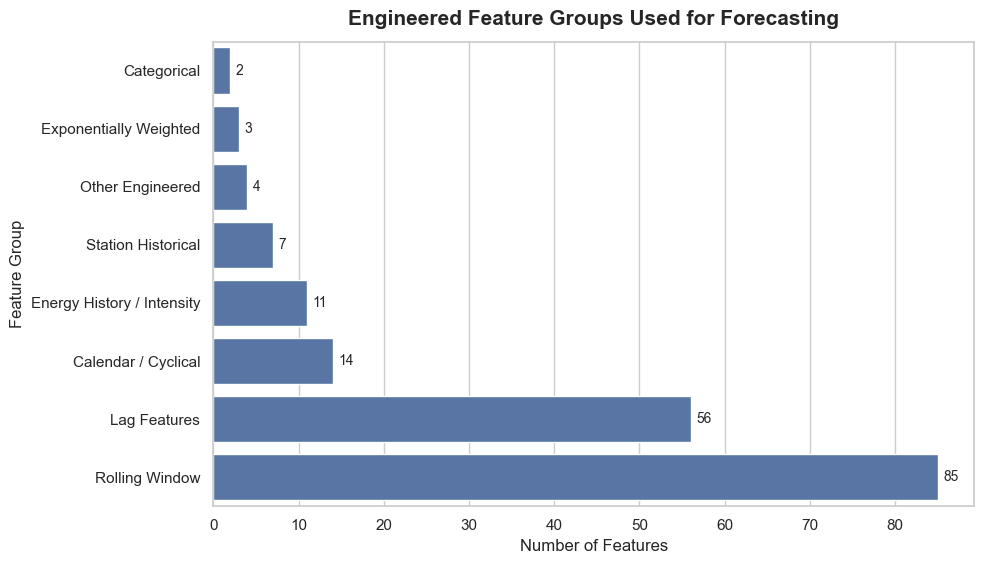

,feature_group,feature_count
6,Rolling Window,85
4,Lag Features,56
0,Calendar / Cyclical,14
2,Energy History / Intensity,11
7,Station Historical,7
5,Other Engineered,4
3,Exponentially Weighted,3
1,Categorical,2


In [81]:
# Feature Engineering Graph 2: Engineered Feature Groups

def classify_feature_group(feature_name):
    name = feature_name.lower()

    if feature_name in CATEGORICAL_FEATURES:
        return "Categorical"

    if name in [
        "hour", "day_of_week", "month", "quarter", "season",
        "is_weekend", "is_holiday", "is_peak_hour",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos",
        "month_sin", "month_cos"
    ]:
        return "Calendar / Cyclical"

    if name.startswith("lag_") or "global_lag" in name or "energy_lag" in name:
        return "Lag Features"

    if "rolling" in name:
        return "Rolling Window"

    if "ewm" in name:
        return "Exponentially Weighted"

    if "expanding" in name or "station_hour" in name or "station_dow" in name or "station_weekend" in name:
        return "Station Historical"

    if "energy" in name:
        return "Energy History / Intensity"

    if "_x_" in name or "ratio" in name or "trend" in name or "delta" in name or "acceleration" in name:
        return "Interaction / Derived"

    return "Other Engineered"

# Combine the features used across both forecasting tasks
all_model_features = sorted(
    set(base_numeric_features)
    | set(energy_numeric_features)
    | set(CATEGORICAL_FEATURES)
)

feature_group_df = pd.DataFrame({
    "feature": all_model_features
})

feature_group_df["feature_group"] = feature_group_df["feature"].apply(classify_feature_group)

feature_group_summary = (
    feature_group_df
    .groupby("feature_group", as_index=False)
    .agg(feature_count=("feature", "count"))
    .sort_values("feature_count", ascending=True)
)

feature_group_df.to_csv(
    OUTPUT_DIR / "engineered_feature_group_mapping.csv",
    index=False
)

feature_group_summary.to_csv(
    OUTPUT_DIR / "engineered_feature_group_summary.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(10, 5.8))

sns.barplot(
    data=feature_group_summary,
    x="feature_count",
    y="feature_group",
    ax=ax
)

ax.set_title(
    "Engineered Feature Groups Used for Forecasting",
    fontsize=15,
    weight="bold",
    pad=12
)
ax.set_xlabel("Number of Features", fontsize=12)
ax.set_ylabel("Feature Group", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=4, fontsize=10)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "feature_engineering_group_summary.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

display(feature_group_summary.sort_values("feature_count", ascending=False))

## 12. Model Comparison Across Forecasting Tasks
This section creates comparison tables and figures for both forecasting targets. It summarizes R², MAE, RMSE, WMAPE, and improvement over temporal baselines for demand and energy models.


### Prepare Clean Model Comparison Tables
The raw model-result tables are standardized into presentation-ready tables with readable model names and R² expressed as a percentage.


In [68]:

# Prepare Model Comparison Tables for Demand and Energy Models

import pandas as pd
import numpy as np


model_name_map = {
    "Baseline_lag_1h_sessions": "Lag-1h Baseline",
    "Baseline_energy_lag_1h": "Lag-1h Baseline",
    "Baseline_blend_recent_daily_weekly": "Recent/Daily/Weekly Baseline",
    "Ridge_L2": "Ridge Regression",
    "Lasso_L1": "Lasso Regression",
    "HistGradientBoosting_squared_tuned": "HistGradientBoosting",
    "LightGBM_squared": "LightGBM",
    "Blend_top_demand_models": "Model Blend",
    "CatBoost_RMSE": "CatBoost",
}

def prepare_model_comparison_table(results_df, task_name):
    table = results_df.copy()

    # Standardize R² column name if needed
    if "R²" not in table.columns and "R2" in table.columns:
        table = table.rename(columns={"R2": "R²"})

    table["Task"] = task_name
    table["Model Label"] = table["Model"].map(model_name_map).fillna(table["Model"])

    # Convert R² to percent for presentation
    table["R² (%)"] = table["R²"] * 100

    # Rounded display columns
    table["MAE"] = table["MAE"].astype(float)
    table["RMSE"] = table["RMSE"].astype(float)
    table["WMAPE (%)"] = table["WMAPE (%)"].astype(float)

    display_table = table[
        ["Task", "Model Label", "MAE", "RMSE", "R² (%)", "WMAPE (%)"]
    ].copy()

    display_table = display_table.round({
        "MAE": 3,
        "RMSE": 3,
        "R² (%)": 2,
        "WMAPE (%)": 2,
    })

    return table, display_table


demand_plot_table, demand_display_table = prepare_model_comparison_table(
    demand_results,
    "Demand Forecasting"
)

energy_plot_table, energy_display_table = prepare_model_comparison_table(
    energy_results,
    "Energy Forecasting"
)

combined_model_comparison = pd.concat(
    [demand_display_table, energy_display_table],
    ignore_index=True
)

combined_model_comparison.to_csv(
    OUTPUT_DIR / "combined_model_comparison_table.csv",
    index=False
)

print("Demand Model Comparison Table")
display(demand_display_table)

print("Energy Model Comparison Table")
display(energy_display_table)

print("Combined Model Comparison Table")
display(combined_model_comparison)

Demand Model Comparison Table


,Task,Model Label,MAE,RMSE,R² (%),WMAPE (%)
0,Demand Forecasting,Lag-1h Baseline,0.130,0.416,56.67,31.32
1,Demand Forecasting,Recent/Daily/Weekly Baseline,0.247,0.441,51.33,59.30
2,Demand Forecasting,Ridge Regression,0.175,0.360,67.62,41.99
3,Demand Forecasting,Lasso Regression,0.177,0.360,67.48,42.47
4,Demand Forecasting,HistGradientBoosting,0.142,0.329,72.88,34.07
5,Demand Forecasting,LightGBM,0.140,0.328,73.06,33.63
6,Demand Forecasting,Model Blend,0.141,0.328,73.07,33.80


Energy Model Comparison Table


,Task,Model Label,MAE,RMSE,R² (%),WMAPE (%)
0,Energy Forecasting,Lag-1h Baseline,1.544,6.049,33.51,58.90
1,Energy Forecasting,Recent/Daily/Weekly Baseline,1.970,5.391,47.19,75.12
2,Energy Forecasting,Ridge Regression,1.652,4.746,59.07,63.01
3,Energy Forecasting,Lasso Regression,1.651,4.747,59.06,62.98
4,Energy Forecasting,HistGradientBoosting,1.420,4.656,60.61,54.17
5,Energy Forecasting,CatBoost,1.420,4.644,60.82,54.17


Combined Model Comparison Table


,Task,Model Label,MAE,RMSE,R² (%),WMAPE (%)
0,Demand Forecasting,Lag-1h Baseline,0.130,0.416,56.67,31.32
1,Demand Forecasting,Recent/Daily/Weekly Baseline,0.247,0.441,51.33,59.30
2,Demand Forecasting,Ridge Regression,0.175,0.360,67.62,41.99
3,Demand Forecasting,Lasso Regression,0.177,0.360,67.48,42.47
4,Demand Forecasting,HistGradientBoosting,0.142,0.329,72.88,34.07
5,Demand Forecasting,LightGBM,0.140,0.328,73.06,33.63
6,Demand Forecasting,Model Blend,0.141,0.328,73.07,33.80
7,Energy Forecasting,Lag-1h Baseline,1.544,6.049,33.51,58.90
8,Energy Forecasting,Recent/Daily/Weekly Baseline,1.970,5.391,47.19,75.12
9,Energy Forecasting,Ridge Regression,1.652,4.746,59.07,63.01


### R² Comparison for Demand and Energy Models
This figure compares the variance explained by each model on the future test period. R² is reported as a score, not as classification accuracy.


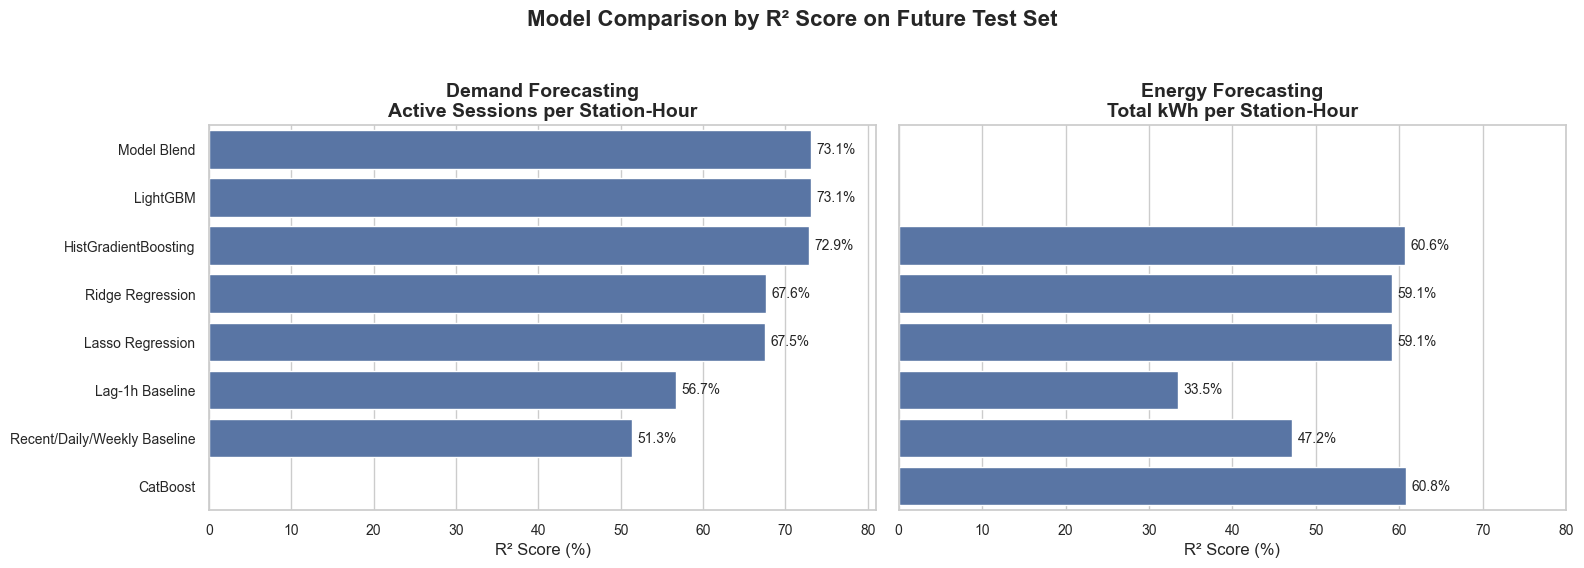

In [72]:
# Figure: R² Comparison for Demand and Energy Forecasting Models
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

plot_specs = [
    (axes[0], demand_plot_table, "Demand Forecasting\nActive Sessions per Station-Hour"),
    (axes[1], energy_plot_table, "Energy Forecasting\nTotal kWh per Station-Hour"),
]

for ax, plot_df, title in plot_specs:
    plot_df = plot_df.copy()
    plot_df["R² (%)"] = plot_df["R²"] * 100
    plot_df = plot_df.sort_values("R² (%)", ascending=False)

    sns.barplot(
        data=plot_df,
        x="R² (%)",
        y="Model Label",
        ax=ax
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("R² Score (%)", fontsize=12)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=10)

    # Add value labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=4,
            fontsize=10
        )

    # Keep axis clean and readable
    min_x = min(0, plot_df["R² (%)"].min() - 5)
    max_x = max(80, plot_df["R² (%)"].max() + 8)
    ax.set_xlim(min_x, max_x)

fig.suptitle(
    "Model Comparison by R² Score on Future Test Set",
    fontsize=16,
    weight="bold",
    y=1.03
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "model_comparison_r2_percent_demand_energy.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

### MAE Comparison for Demand and Energy Models
This figure compares average absolute prediction error. Demand MAE is measured in active sessions, while energy MAE is measured in kWh.


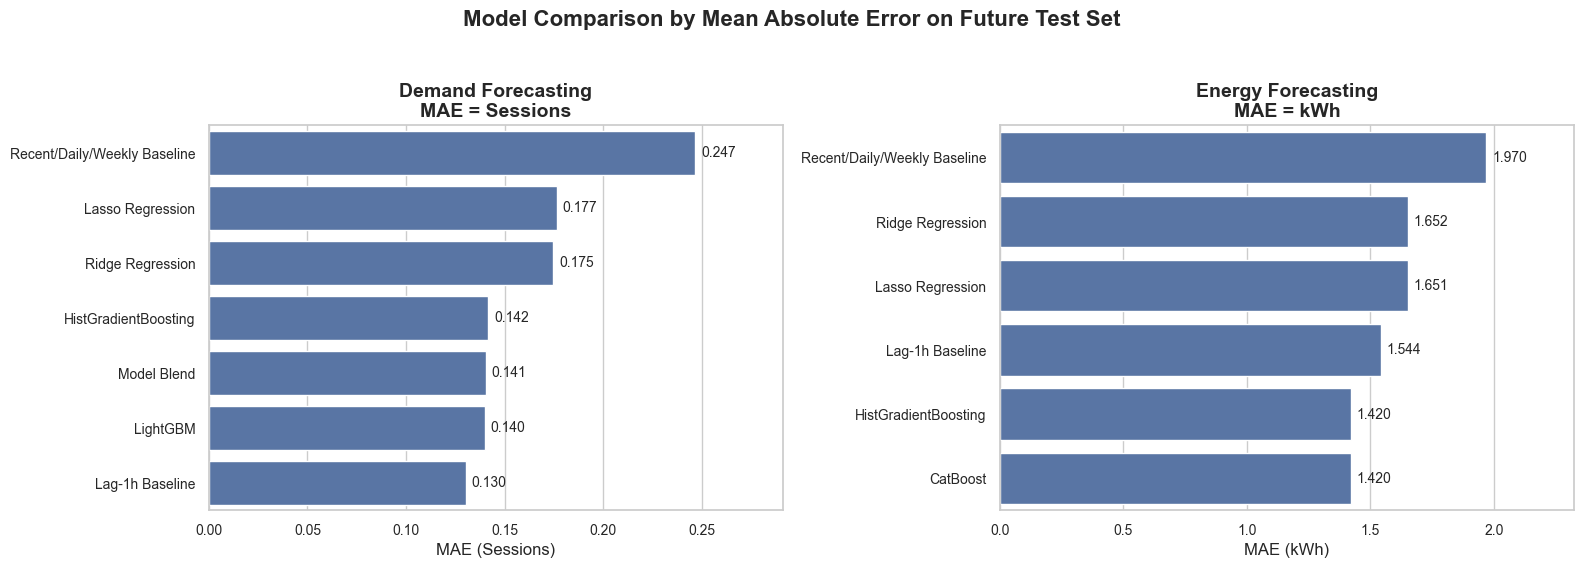

In [ ]:
# Figure: MAE Comparison for Demand and Energy Forecasting Models

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

plot_specs = [
    (
        axes[0],
        demand_plot_table.sort_values("MAE", ascending=False),
        "Demand Forecasting\nMAE = Sessions",
        "MAE (Sessions)"
    ),
    (
        axes[1],
        energy_plot_table.sort_values("MAE", ascending=False),
        "Energy Forecasting\nMAE = kWh",
        "MAE (kWh)"
    ),
]

for ax, plot_df, title, xlabel in plot_specs:
    sns.barplot(
        data=plot_df,
        x="MAE",
        y="Model Label",
        ax=ax
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=10)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=4,
            fontsize=10
        )

    ax.set_xlim(0, plot_df["MAE"].max() * 1.18)

fig.suptitle(
    "Model Comparison by Mean Absolute Error on Future Test Set",
    fontsize=16,
    weight="bold",
    y=1.03
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "model_comparison_mae_demand_energy.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

### RMSE Comparison for Demand and Energy Models
This figure compares root mean squared error, which penalizes large misses more strongly than MAE. It is useful for understanding how models behave when station-hour spikes occur.


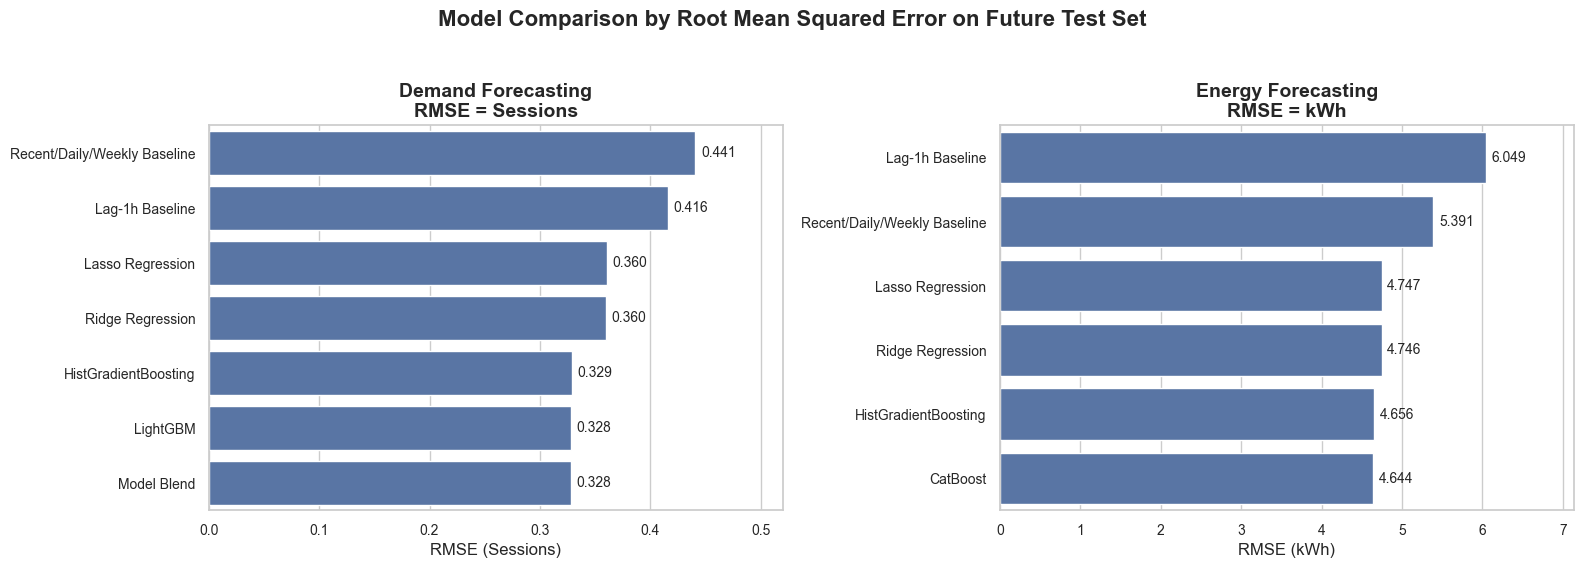

In [71]:
# Figure: RMSE Comparison for Demand and Energy Forecasting Models

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

plot_specs = [
    (
        axes[0],
        demand_plot_table.sort_values("RMSE", ascending=False),
        "Demand Forecasting\nRMSE = Sessions",
        "RMSE (Sessions)"
    ),
    (
        axes[1],
        energy_plot_table.sort_values("RMSE", ascending=False),
        "Energy Forecasting\nRMSE = kWh",
        "RMSE (kWh)"
    ),
]

for ax, plot_df, title, xlabel in plot_specs:
    sns.barplot(
        data=plot_df,
        x="RMSE",
        y="Model Label",
        ax=ax
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=10)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=4,
            fontsize=10
        )

    ax.set_xlim(0, plot_df["RMSE"].max() * 1.18)

fig.suptitle(
    "Model Comparison by Root Mean Squared Error on Future Test Set",
    fontsize=16,
    weight="bold",
    y=1.03
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "model_comparison_rmse_demand_energy.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

### Combined Metric Summary: R², MAE, RMSE, and WMAPE
These figures summarize multiple evaluation metrics for each target so the models can be compared from both variance-explained and error-magnitude perspectives.


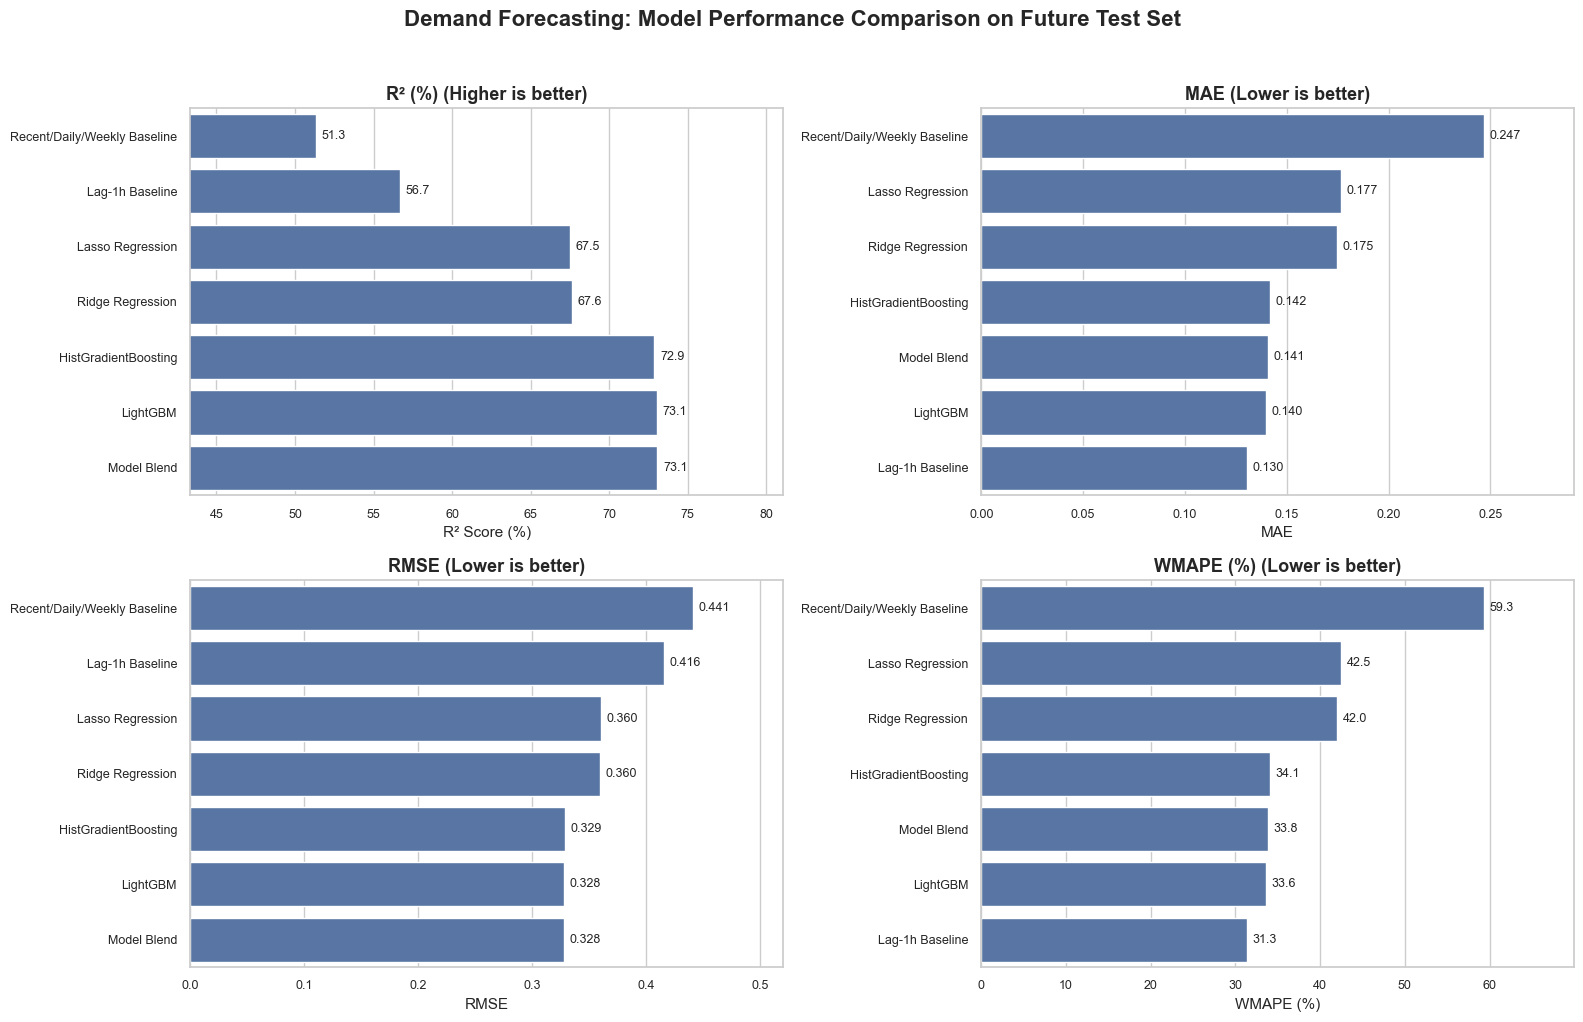

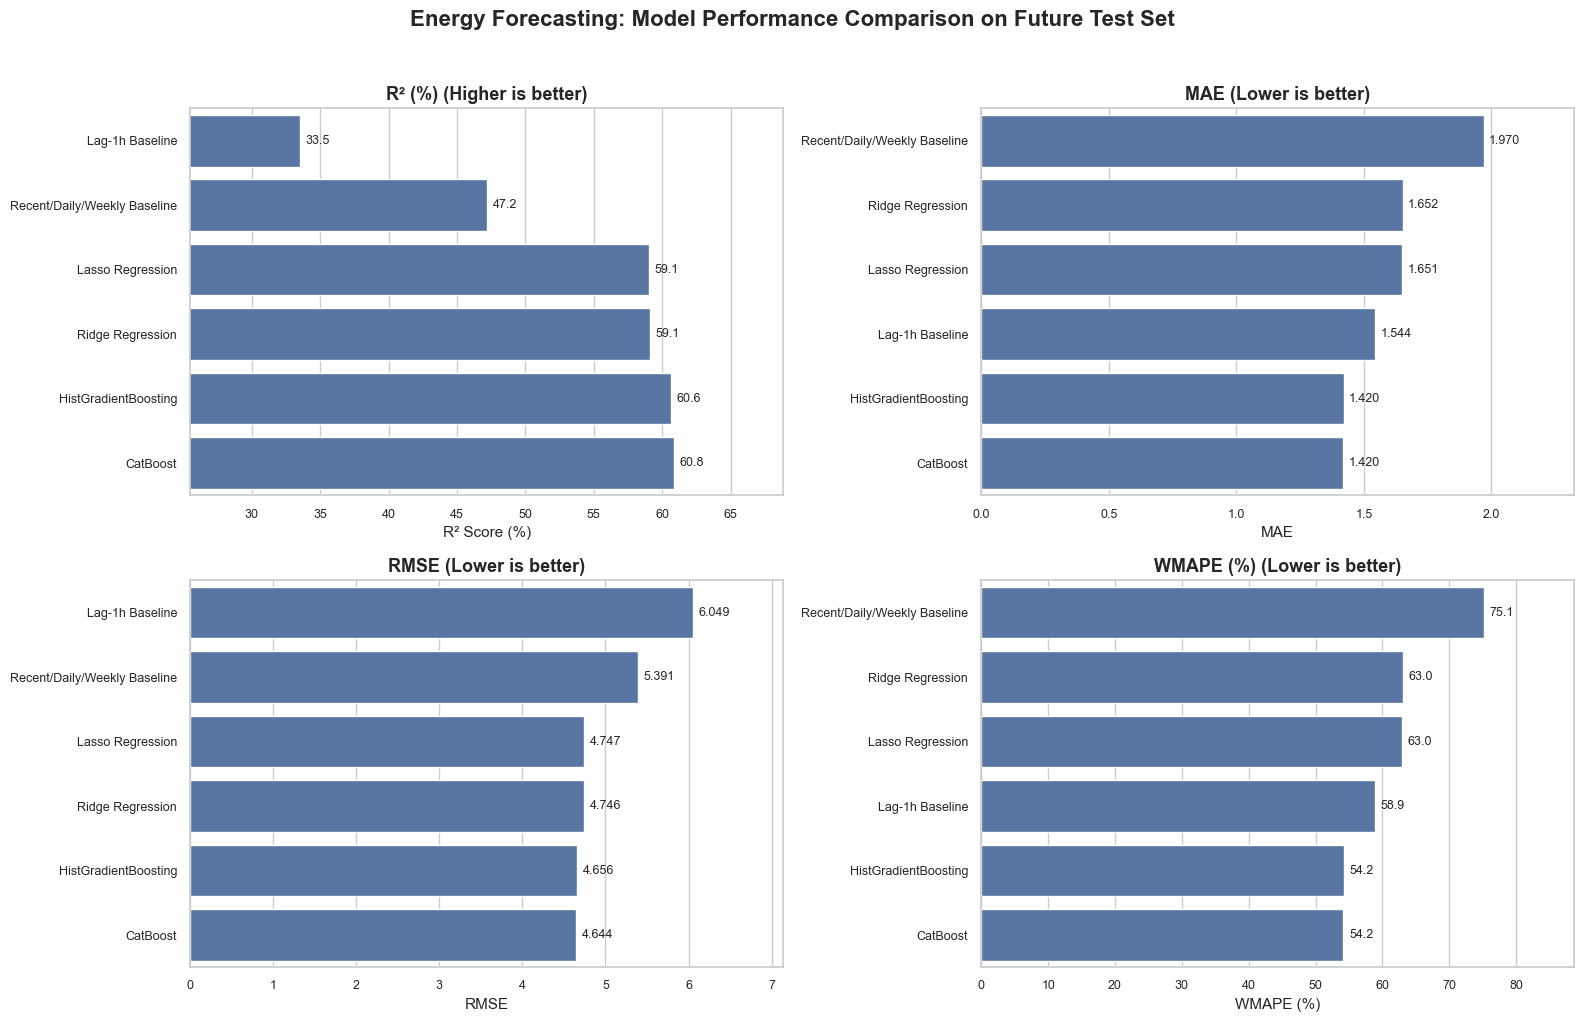

In [73]:
comparison_for_plot = pd.concat(
    [demand_plot_table, energy_plot_table],
    ignore_index=True
).copy()

comparison_for_plot["R² (%)"] = comparison_for_plot["R²"] * 100

metric_specs = [
    ("R² (%)", "Higher is better", "R² Score (%)"),
    ("MAE", "Lower is better", "MAE"),
    ("RMSE", "Lower is better", "RMSE"),
    ("WMAPE (%)", "Lower is better", "WMAPE (%)"),
]

for task_name in ["Demand Forecasting", "Energy Forecasting"]:
    task_df = comparison_for_plot[comparison_for_plot["Task"] == task_name].copy()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (metric, direction, xlabel) in zip(axes, metric_specs):
        ascending = False if metric == "R² (%)" else True
        plot_df = task_df.sort_values(metric, ascending=ascending).copy()

        # For horizontal chart, reverse for visual ordering
        plot_df = plot_df.iloc[::-1]

        sns.barplot(
            data=plot_df,
            x=metric,
            y="Model Label",
            ax=ax
        )

        ax.set_title(f"{metric} ({direction})", fontsize=13, weight="bold")
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel("")
        ax.tick_params(axis="both", labelsize=9)

        for container in ax.containers:
            if metric == "R² (%)" or metric == "WMAPE (%)":
                ax.bar_label(container, fmt="%.1f", padding=4, fontsize=9)
            else:
                ax.bar_label(container, fmt="%.3f", padding=4, fontsize=9)

        max_val = plot_df[metric].max()
        min_val = plot_df[metric].min()

        if metric == "R² (%)":
            ax.set_xlim(max(0, min_val - 8), max_val + 8)
        else:
            ax.set_xlim(0, max_val * 1.18)

    fig.suptitle(
        f"{task_name}: Model Performance Comparison on Future Test Set",
        fontsize=16,
        weight="bold",
        y=1.02
    )

    fig.tight_layout()

    safe_task_name = task_name.lower().replace(" ", "_")
    fig.savefig(
        OUTPUT_DIR / f"{safe_task_name}_model_comparison_all_metrics.png",
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()

### Best Model Improvement over Temporal Baselines
This section quantifies how much the best machine-learning model improves over the lag-1h persistence baseline for both demand and energy forecasting.


,Task,Baseline Model,Best Model,Baseline R² (%),Best R² (%),Absolute R² Gain (points),Baseline MAE,Best MAE,MAE Change (%),Baseline RMSE,Best RMSE,RMSE Reduction (%)
0,Demand Forecasting,Lag-1h Baseline,Model Blend,56.67,73.07,16.40,0.130,0.141,7.93,0.416,0.328,21.16
1,Energy Forecasting,Lag-1h Baseline,CatBoost,33.51,60.82,27.31,1.544,1.420,-8.04,6.049,4.644,23.24


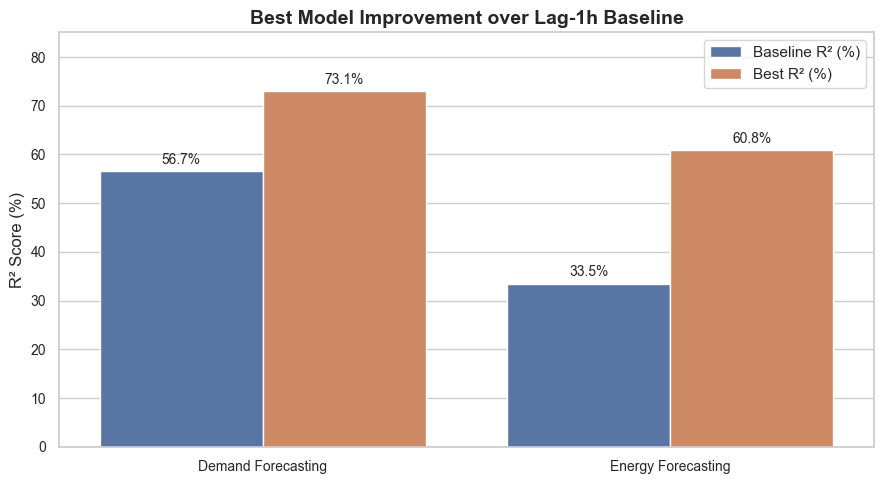

In [74]:
# Best Model Improvement Over Baseline

def best_vs_baseline_summary(plot_table, task_name, baseline_model_name):
    table = plot_table.copy()

    baseline_row = table[table["Model"] == baseline_model_name].iloc[0]
    best_row = table.sort_values("R²", ascending=False).iloc[0]

    summary = {
        "Task": task_name,
        "Baseline Model": baseline_row["Model Label"],
        "Best Model": best_row["Model Label"],
        "Baseline R² (%)": baseline_row["R²"] * 100,
        "Best R² (%)": best_row["R²"] * 100,
        "Absolute R² Gain (points)": (best_row["R²"] - baseline_row["R²"]) * 100,
        "Baseline MAE": baseline_row["MAE"],
        "Best MAE": best_row["MAE"],
        "MAE Change (%)": ((best_row["MAE"] - baseline_row["MAE"]) / baseline_row["MAE"]) * 100,
        "Baseline RMSE": baseline_row["RMSE"],
        "Best RMSE": best_row["RMSE"],
        "RMSE Reduction (%)": ((baseline_row["RMSE"] - best_row["RMSE"]) / baseline_row["RMSE"]) * 100,
    }

    return summary


improvement_summary = pd.DataFrame([
    best_vs_baseline_summary(
        demand_plot_table,
        "Demand Forecasting",
        "Baseline_lag_1h_sessions"
    ),
    best_vs_baseline_summary(
        energy_plot_table,
        "Energy Forecasting",
        "Baseline_energy_lag_1h"
    ),
])

improvement_summary_rounded = improvement_summary.round({
    "Baseline R² (%)": 2,
    "Best R² (%)": 2,
    "Absolute R² Gain (points)": 2,
    "Baseline MAE": 3,
    "Best MAE": 3,
    "MAE Change (%)": 2,
    "Baseline RMSE": 3,
    "Best RMSE": 3,
    "RMSE Reduction (%)": 2,
})

improvement_summary_rounded.to_csv(
    OUTPUT_DIR / "best_model_improvement_over_baseline.csv",
    index=False
)

display(improvement_summary_rounded)


# Plot R² improvement
improvement_plot = improvement_summary_rounded.melt(
    id_vars=["Task"],
    value_vars=["Baseline R² (%)", "Best R² (%)"],
    var_name="Model Type",
    value_name="R² (%)"
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=improvement_plot,
    x="Task",
    y="R² (%)",
    hue="Model Type",
    ax=ax
)

ax.set_title("Best Model Improvement over Lag-1h Baseline", fontsize=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("R² Score (%)")
ax.tick_params(axis="both", labelsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=10)

ax.legend(title="")
ax.set_ylim(0, max(improvement_plot["R² (%)"]) + 12)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "best_model_r2_improvement_over_baseline.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

## 13. User Behavior Clustering
This section aggregates cleaned sessions by `driver_id` and clusters users by charging frequency, energy use, duration, idle time, station diversity, weekend behavior, peak-hour behavior, and inferred charging power. The clustering analysis complements forecasting by describing who uses the network and how.


User behavior cluster summary


,session_count,avg_energy_kwh,total_energy_kwh,avg_duration_min,avg_idle_min,avg_power_kw,station_count,location_count,weekend_rate,peak_hour_rate,user_count
user_cluster,,,,,,,,,,,
0,4.805,23.739,117.958,169.214,55.199,21.314,1.738,1.098,0.336,0.492,17081
1,252.041,24.094,5384.818,184.018,54.001,26.535,10.314,3.175,0.278,0.458,560


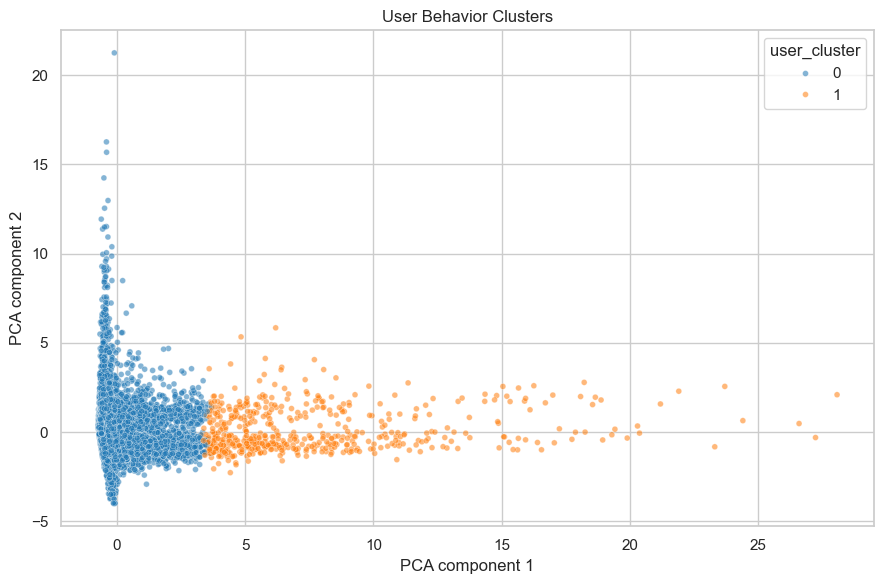

In [ ]:

user_base = sessions.dropna(subset=['driver_id']).copy()
user_base['driver_id'] = user_base['driver_id'].astype(str).str.strip()
user_base = user_base[user_base['driver_id'].str.len() > 0]
user_base['hour'] = user_base['session_start'].dt.hour
user_base['is_weekend'] = (user_base['session_start'].dt.dayofweek >= 5).astype(int)
user_base['is_peak_hour'] = (user_base['hour'].between(7, 10) | user_base['hour'].between(16, 20)).astype(int)
user_base['idle_time_min'] = (user_base['connected_duration_min'] - user_base['charge_duration_min']).clip(lower=0)
user_base['avg_power_kw'] = user_base['energy_provided_kwh'] / (user_base['charge_duration_min'] / 60.0).replace(0, np.nan)

user_features = (
    user_base.groupby('driver_id')
    .agg(
        session_count=('energy_provided_kwh', 'count'),
        avg_energy_kwh=('energy_provided_kwh', 'mean'),
        total_energy_kwh=('energy_provided_kwh', 'sum'),
        avg_duration_min=('charge_duration_min', 'mean'),
        avg_connected_min=('connected_duration_min', 'mean'),
        avg_idle_min=('idle_time_min', 'mean'),
        avg_power_kw=('avg_power_kw', 'mean'),
        station_count=('station_name', 'nunique'),
        location_count=('location_name', 'nunique'),
        weekend_rate=('is_weekend', 'mean'),
        peak_hour_rate=('is_peak_hour', 'mean'),
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

user_cluster_features = [
    'session_count', 'avg_energy_kwh', 'total_energy_kwh', 'avg_duration_min',
    'avg_idle_min', 'avg_power_kw', 'station_count', 'location_count',
    'weekend_rate', 'peak_hour_rate',
]
user_X = user_features[user_cluster_features].fillna(user_features[user_cluster_features].median())
user_X_scaled = StandardScaler().fit_transform(user_X)

k_rows = []
for k in range(2, min(7, len(user_features))):
    labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(user_X_scaled)
    k_rows.append({'k': k, 'silhouette': silhouette_score(user_X_scaled, labels)})
user_k_results = pd.DataFrame(k_rows)
best_user_k = int(user_k_results.sort_values('silhouette', ascending=False).iloc[0]['k']) if len(user_k_results) else 3

user_kmeans = KMeans(n_clusters=best_user_k, n_init=20, random_state=RANDOM_STATE)
user_features['user_cluster'] = user_kmeans.fit_predict(user_X_scaled)
user_cluster_summary = user_features.groupby('user_cluster')[user_cluster_features].mean().round(3)
user_cluster_summary['user_count'] = user_features['user_cluster'].value_counts().sort_index()
user_cluster_summary.to_csv(OUTPUT_DIR / 'user_behavior_cluster_summary.csv')

print('User behavior cluster summary')
display(user_cluster_summary)

user_pca = PCA(n_components=2, random_state=RANDOM_STATE)
user_coords = user_pca.fit_transform(user_X_scaled)
user_plot = user_features.copy()
user_plot['pca_1'] = user_coords[:, 0]
user_plot['pca_2'] = user_coords[:, 1]
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=user_plot, x='pca_1', y='pca_2', hue='user_cluster', palette='tab10', alpha=0.55, s=18, ax=ax)
ax.set_title('User Behavior Clusters')
ax.set_xlabel('PCA component 1')
ax.set_ylabel('PCA component 2')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'user_behavior_clusters.png', dpi=160)
plt.show()


In [60]:
user_base = sessions.dropna(subset=['driver_id']).copy()
user_base['driver_id'] = user_base['driver_id'].astype(str).str.strip()
user_base = user_base[user_base['driver_id'].str.len() > 0]

user_base['hour'] = user_base['session_start'].dt.hour
user_base['is_weekend'] = (user_base['session_start'].dt.dayofweek >= 5).astype(int)
user_base['is_peak_hour'] = (
    user_base['hour'].between(7, 10) | user_base['hour'].between(16, 20)
).astype(int)

user_base['idle_time_min'] = (
    user_base['connected_duration_min'] - user_base['charge_duration_min']
).clip(lower=0)

user_base['avg_power_kw'] = (
    user_base['energy_provided_kwh'] /
    (user_base['charge_duration_min'] / 60.0).replace(0, np.nan)
)

user_features = (
    user_base.groupby('driver_id')
    .agg(
        session_count=('energy_provided_kwh', 'count'),
        avg_energy_kwh=('energy_provided_kwh', 'mean'),
        total_energy_kwh=('energy_provided_kwh', 'sum'),
        avg_duration_min=('charge_duration_min', 'mean'),
        avg_connected_min=('connected_duration_min', 'mean'),
        avg_idle_min=('idle_time_min', 'mean'),
        avg_power_kw=('avg_power_kw', 'mean'),
        station_count=('station_name', 'nunique'),
        location_count=('location_name', 'nunique'),
        weekend_rate=('is_weekend', 'mean'),
        peak_hour_rate=('is_peak_hour', 'mean'),
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

user_cluster_features = [
    'session_count',
    'avg_energy_kwh',
    'total_energy_kwh',
    'avg_duration_min',
    'avg_idle_min',
    'avg_power_kw',
    'station_count',
    'location_count',
    'weekend_rate',
    'peak_hour_rate',
]

user_X = user_features[user_cluster_features].copy()
user_X = user_X.fillna(user_X.median())

# Standardize
scaler = StandardScaler()
user_X_scaled = scaler.fit_transform(user_X)


k_rows = []
candidate_ks = list(range(2, min(7, len(user_features))))

for k in candidate_ks:
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(user_X_scaled)
    score = silhouette_score(user_X_scaled, labels)

    k_rows.append({
        'k': k,
        'silhouette': score
    })

user_k_results = (
    pd.DataFrame(k_rows)
    .sort_values('silhouette', ascending=False)
    .reset_index(drop=True)
)

user_k_results.to_csv(OUTPUT_DIR / 'user_behavior_silhouette_scores.csv', index=False)

print("Silhouette ranking for user behavior clustering")
display(user_k_results)


top_k_values = user_k_results['k'].head(2).tolist()


if len(top_k_values) == 1:
    top_k_values.append(top_k_values[0] + 1)

best_k = int(top_k_values[0])
second_best_k = int(top_k_values[1])

print(f"Best k by silhouette: {best_k}")
print(f"Second-best k by silhouette: {second_best_k}")


user_pca = PCA(n_components=2, random_state=RANDOM_STATE)
user_coords = user_pca.fit_transform(user_X_scaled)

user_plot_base = user_features.copy()
user_plot_base['pca_1'] = user_coords[:, 0]
user_plot_base['pca_2'] = user_coords[:, 1]

Silhouette ranking for user behavior clustering


,k,silhouette
0,2,0.628926
1,6,0.233322
2,5,0.216841
3,4,0.193245
4,3,0.184167


Best k by silhouette: 2
Second-best k by silhouette: 6


User behavior cluster summary for k=2


,session_count,avg_energy_kwh,total_energy_kwh,avg_duration_min,avg_idle_min,avg_power_kw,station_count,location_count,weekend_rate,peak_hour_rate,user_count
user_cluster,,,,,,,,,,,
0,4.805,23.739,117.958,169.214,55.199,21.314,1.738,1.098,0.336,0.492,17081
1,252.041,24.094,5384.818,184.018,54.001,26.535,10.314,3.175,0.278,0.458,560


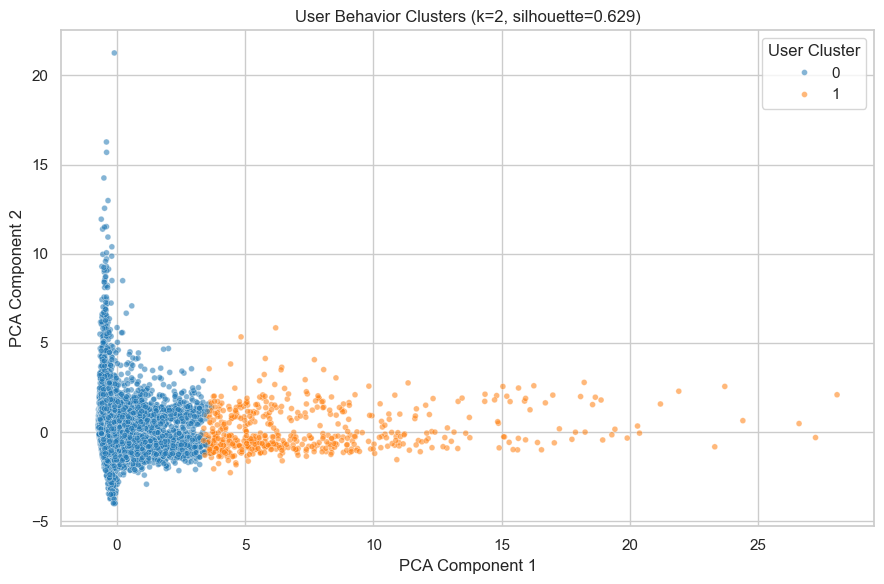

User behavior cluster summary for k=6


,session_count,avg_energy_kwh,total_energy_kwh,avg_duration_min,avg_idle_min,avg_power_kw,station_count,location_count,weekend_rate,peak_hour_rate,user_count
user_cluster,,,,,,,,,,,
0,1.818,15.559,29.259,116.281,16.950,15.230,1.318,1.033,0.964,0.434,3875
1,5.011,39.318,164.182,54.973,0.773,48.921,1.625,1.083,0.242,0.425,4439
2,73.444,25.371,1726.330,175.367,45.028,25.155,8.004,2.638,0.279,0.488,1052
3,595.926,21.791,12185.140,173.470,49.994,28.315,10.554,2.878,0.288,0.402,148
4,3.414,13.142,53.068,140.768,29.369,9.782,1.576,1.055,0.038,0.561,6677
5,3.912,45.855,147.806,792.212,450.430,4.678,1.819,1.022,0.345,0.539,1450


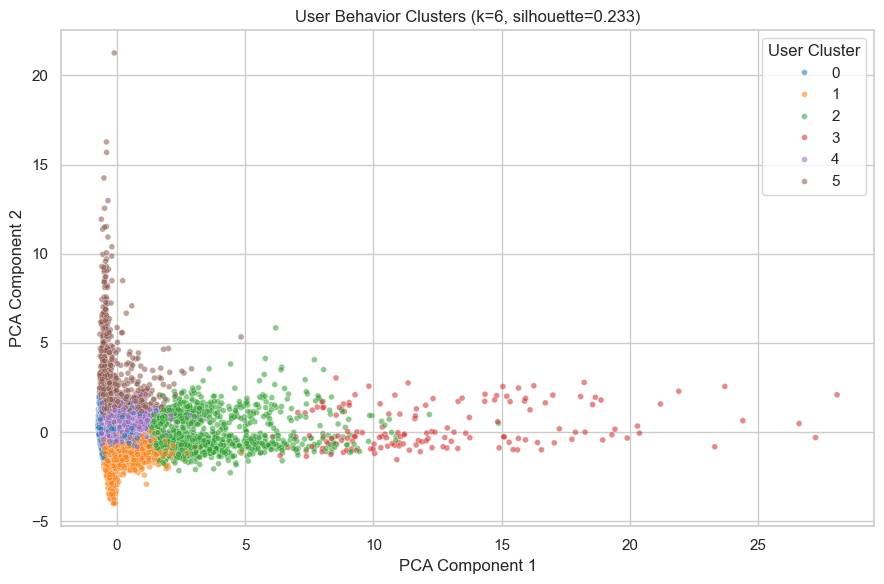

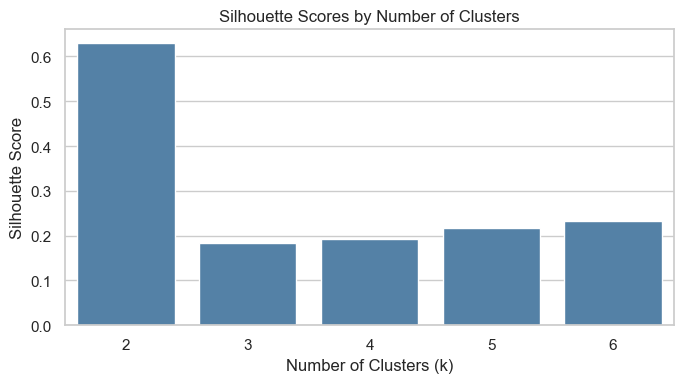

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_k_values = [best_k, second_best_k]

for rank_idx, k in enumerate(selected_k_values, start=1):
    # Fit clustering model
    kmeans_model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    cluster_labels = kmeans_model.fit_predict(user_X_scaled)
    sil_score = silhouette_score(user_X_scaled, cluster_labels)

    # Add cluster labels to copies
    plot_df = user_plot_base.copy()
    plot_df['user_cluster'] = cluster_labels

    summary_df = (
        plot_df.groupby('user_cluster')[user_cluster_features]
        .mean()
        .round(3)
    )
    summary_df['user_count'] = plot_df['user_cluster'].value_counts().sort_index()

    # Save summary for this k
    summary_df.to_csv(OUTPUT_DIR / f'user_behavior_cluster_summary_k{k}.csv')

    print(f'User behavior cluster summary for k={k}')
    display(summary_df)


    fig, ax = plt.subplots(figsize=(9, 6))

    sns.scatterplot(
        data=plot_df,
        x='pca_1',
        y='pca_2',
        hue='user_cluster',
        palette='tab10',
        alpha=0.55,
        s=18,
        ax=ax
    )

    ax.set_title(
        f'User Behavior Clusters (k={k}, silhouette={sil_score:.3f})'
    )
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(title='User Cluster')

    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f'user_behavior_clusters_k{k}.png',
        dpi=160,
        bbox_inches='tight'
    )
    plt.show()


fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=user_k_results.sort_values('k'),
    x='k',
    y='silhouette',
    color='steelblue',
    ax=ax
)

ax.set_title('Silhouette Scores by Number of Clusters')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / 'user_behavior_silhouette_comparison.png',
    dpi=160,
    bbox_inches='tight'
)
plt.show()

In [64]:
# ============================================================
# Labeled User Behavior Cluster Table for k=6
# ============================================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# Choose k = 6 because this produced interpretable user segments
# ------------------------------------------------------------
selected_k = 6

# Safety check
if selected_k >= len(user_features):
    raise ValueError(f"selected_k={selected_k} is too large for {len(user_features)} users.")

# ------------------------------------------------------------
# Fit k=6 clustering and store labels directly in user_features
# ------------------------------------------------------------
user_kmeans_k6 = KMeans(
    n_clusters=selected_k,
    n_init=20,
    random_state=RANDOM_STATE
)

user_features_labeled = user_features.copy()
user_features_labeled["user_cluster"] = user_kmeans_k6.fit_predict(user_X_scaled)

k6_silhouette = silhouette_score(
    user_X_scaled,
    user_features_labeled["user_cluster"]
)

print(f"k={selected_k} silhouette score: {k6_silhouette:.3f}")

# ------------------------------------------------------------
# Cluster labels and descriptions based on your k=6 output
# ------------------------------------------------------------
user_cluster_labels = {
    0: "Weekend Occasional Chargers",
    1: "Fast High-Energy Top-Up Users",
    2: "Frequent Multi-Station Users",
    3: "Extreme High-Utilization Users",
    4: "Weekday Peak-Hour Local Chargers",
    5: "Long-Dwell Low-Power Users",
}

user_cluster_descriptions = {
    0: "Low-frequency users who charge mostly on weekends, with low total energy and limited station diversity.",
    1: "Short-duration, high-power, high-energy charging users with minimal idle time.",
    2: "Regular users with many sessions, high total energy use, and charging across multiple stations.",
    3: "Very small but extremely heavy users with exceptionally high session counts and total energy demand.",
    4: "Mostly weekday users with peak-hour charging behavior, low energy per session, and local station usage.",
    5: "Users with very long connection times, high idle time, and relatively low charging power.",
}

# ------------------------------------------------------------
# Build summary table
# ------------------------------------------------------------
user_cluster_summary_labeled = (
    user_features_labeled
    .groupby("user_cluster")[user_cluster_features]
    .mean()
    .round(3)
)

user_cluster_summary_labeled["user_count"] = (
    user_features_labeled["user_cluster"]
    .value_counts()
    .sort_index()
)

user_cluster_summary_labeled["cluster_label"] = (
    user_cluster_summary_labeled.index.map(user_cluster_labels)
)

user_cluster_summary_labeled["description"] = (
    user_cluster_summary_labeled.index.map(user_cluster_descriptions)
)

# Add silhouette score as metadata column
user_cluster_summary_labeled["silhouette_k6"] = round(k6_silhouette, 3)

# Reorder columns
ordered_cols = [
    "cluster_label",
    "description",
    "user_count",
    "session_count",
    "avg_energy_kwh",
    "total_energy_kwh",
    "avg_duration_min",
    "avg_idle_min",
    "avg_power_kw",
    "station_count",
    "location_count",
    "weekend_rate",
    "peak_hour_rate",
    "silhouette_k6",
]

user_cluster_summary_labeled = user_cluster_summary_labeled[ordered_cols]

# Save table
user_cluster_summary_labeled.to_csv(
    OUTPUT_DIR / "user_behavior_cluster_summary_k6_labeled.csv",
    index=True
)

print("Labeled user behavior cluster summary for k=6")
display(user_cluster_summary_labeled)

k=6 silhouette score: 0.233
Labeled user behavior cluster summary for k=6


,cluster_label,description,user_count,session_count,avg_energy_kwh,total_energy_kwh,avg_duration_min,avg_idle_min,avg_power_kw,station_count,location_count,weekend_rate,peak_hour_rate,silhouette_k6
user_cluster,,,,,,,,,,,,,,
0,Weekend Occasional Chargers,Low-frequency users who charge mostly on weeke...,3875,1.818,15.559,29.259,116.281,16.950,15.230,1.318,1.033,0.964,0.434,0.233
1,Fast High-Energy Top-Up Users,"Short-duration, high-power, high-energy chargi...",4439,5.011,39.318,164.182,54.973,0.773,48.921,1.625,1.083,0.242,0.425,0.233
2,Frequent Multi-Station Users,"Regular users with many sessions, high total e...",1052,73.444,25.371,1726.330,175.367,45.028,25.155,8.004,2.638,0.279,0.488,0.233
3,Extreme High-Utilization Users,Very small but extremely heavy users with exce...,148,595.926,21.791,12185.140,173.470,49.994,28.315,10.554,2.878,0.288,0.402,0.233
4,Weekday Peak-Hour Local Chargers,Mostly weekday users with peak-hour charging b...,6677,3.414,13.142,53.068,140.768,29.369,9.782,1.576,1.055,0.038,0.561,0.233
5,Long-Dwell Low-Power Users,"Users with very long connection times, high id...",1450,3.912,45.855,147.806,792.212,450.430,4.678,1.819,1.022,0.345,0.539,0.233


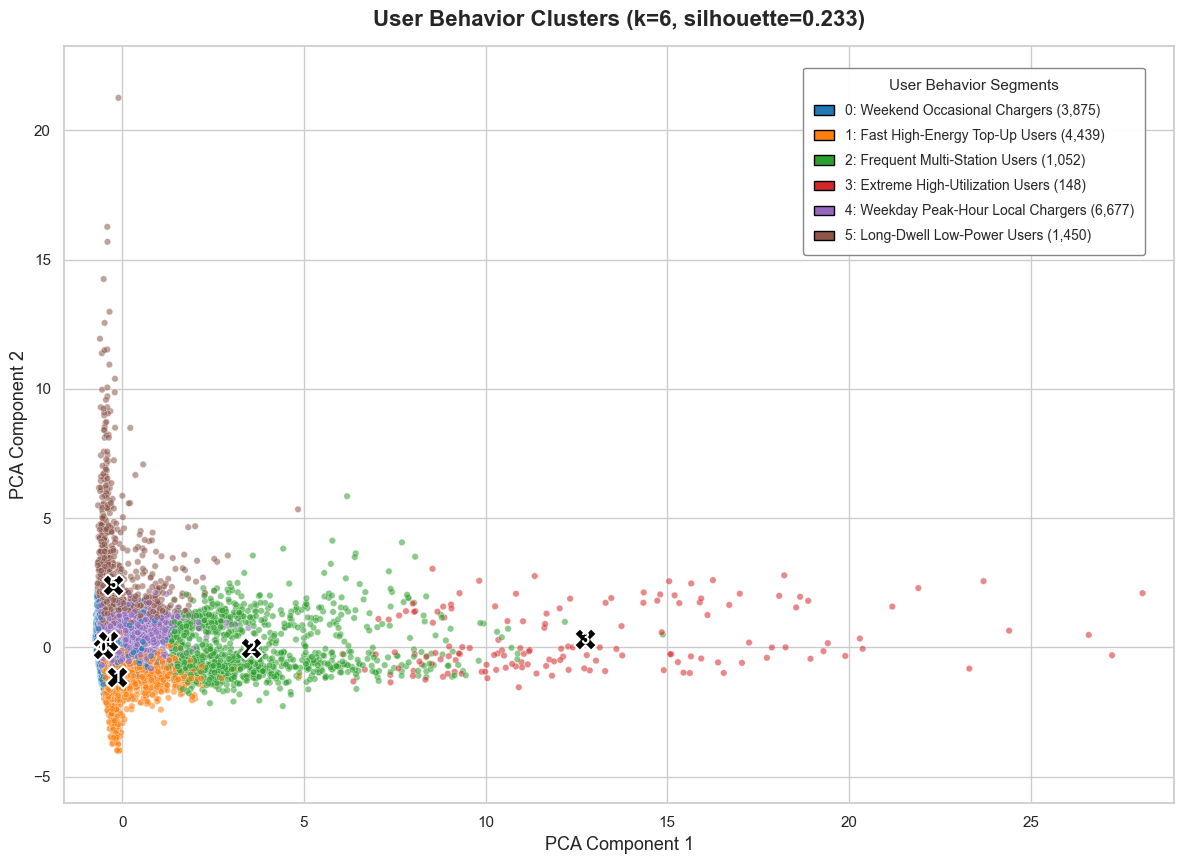

In [67]:
# ============================================================
# User Behavior Cluster Figure for k=6
# Cleaner legend with color boxes, larger fonts, slightly taller figure
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
required_objects = [
    "user_features_labeled",
    "user_cluster_summary_labeled",
    "user_cluster_labels",
    "user_X_scaled",
    "k6_silhouette",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is missing. Run the labeled table cell first.")

# ------------------------------------------------------------
# PCA projection
# ------------------------------------------------------------
user_pca = PCA(n_components=2, random_state=RANDOM_STATE)
user_coords = user_pca.fit_transform(user_X_scaled)

user_plot_labeled = user_features_labeled.copy()
user_plot_labeled["pca_1"] = user_coords[:, 0]
user_plot_labeled["pca_2"] = user_coords[:, 1]

# ------------------------------------------------------------
# Cluster centroid positions
# ------------------------------------------------------------
cluster_centroids = (
    user_plot_labeled
    .groupby("user_cluster")[["pca_1", "pca_2"]]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# Color palette
# ------------------------------------------------------------
cluster_ids = sorted(user_cluster_labels.keys())
palette = sns.color_palette("tab10", n_colors=len(cluster_ids))
cluster_color_map = {cluster_id: palette[i] for i, cluster_id in enumerate(cluster_ids)}

# ------------------------------------------------------------
# Legend labels with color boxes
# ------------------------------------------------------------
legend_handles = []
for cluster_id in cluster_ids:
    label_name = user_cluster_labels[cluster_id]
    user_count = int(user_cluster_summary_labeled.loc[cluster_id, "user_count"])
    legend_handles.append(
        Patch(
            facecolor=cluster_color_map[cluster_id],
            edgecolor="black",
            label=f"{cluster_id}: {label_name} ({user_count:,})"
        )
    )

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8.8))  # slightly taller

sns.scatterplot(
    data=user_plot_labeled,
    x="pca_1",
    y="pca_2",
    hue="user_cluster",
    palette=cluster_color_map,
    alpha=0.55,
    s=22,
    ax=ax,
    legend=False
)

# Add centroid markers and cluster numbers
for _, row in cluster_centroids.iterrows():
    cluster_id = int(row["user_cluster"])

    ax.scatter(
        row["pca_1"],
        row["pca_2"],
        s=260,
        marker="X",
        color="black",
        edgecolor="white",
        linewidth=1.4,
        zorder=5
    )

    ax.text(
        row["pca_1"],
        row["pca_2"],
        f"{cluster_id}",
        fontsize=12,
        weight="bold",
        color="white",
        ha="center",
        va="center",
        zorder=6
    )

# Slightly more vertical breathing room
ax.margins(x=0.03, y=0.08)

# Titles and labels
ax.set_title(
    f"User Behavior Clusters (k=6, silhouette={k6_silhouette:.3f})",
    fontsize=16,
    weight="bold",
    pad=14
)
ax.set_xlabel("PCA Component 1", fontsize=13)
ax.set_ylabel("PCA Component 2", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

# Legend inside plot, top-right, with color boxes
legend = ax.legend(
    handles=legend_handles,
    title="User Behavior Segments",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    borderpad=0.8,
    labelspacing=0.8,
    handlelength=1.4,
    fontsize=10,
    title_fontsize=11
)

# Improve legend alignment
legend.get_frame().set_edgecolor("gray")

fig.tight_layout()

# Save figure
fig.savefig(
    OUTPUT_DIR / "user_behavior_clusters_k6_labeled_clean.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

## 14. Seven-Day Future Demand Forecast
The selected demand pipeline is used to forecast station-hour demand for the next 168 hours. Forecasts are also aggregated into station-day totals and a system-wide demand curve for planning use.


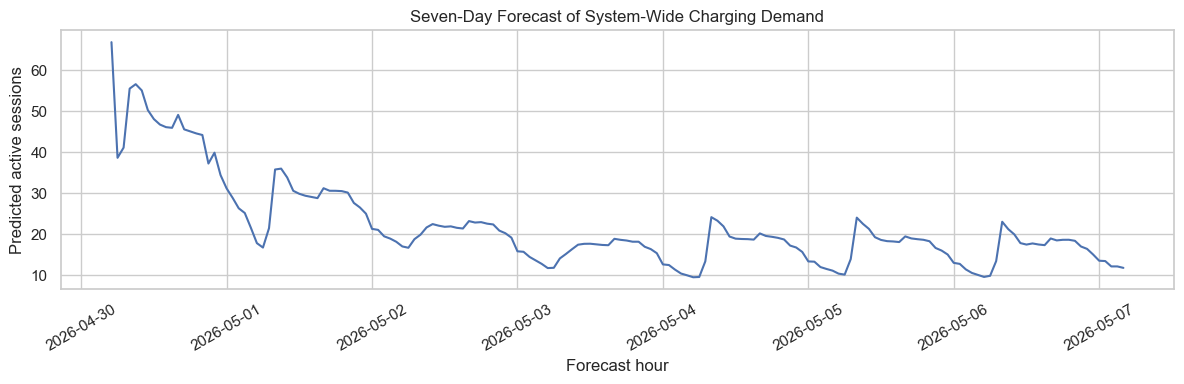

,forecast_date,station_name,location_name,predicted_sessions
51,2026-04-30,BTCE00,QBO - Queens Borough Hall Municipal Parking Ga...,21.727045
33,2026-04-30,101337,Queens Borough Hall Municipal Parking Garage,17.932925
184,2026-04-30,EVB304,CSQ - Court Square Municipal Parking Garage,17.799589
145,2026-04-30,EV0437,Court Square Municipal Parking Garage,16.707923
149,2026-04-30,EV0445,Delancey and Essex Municipal Parking Garage,16.570824
151,2026-04-30,EV0447,Delancey and Essex Municipal Parking Garage,16.545154
153,2026-04-30,EV0448,Delancey and Essex Municipal Parking Garage,16.409352
32,2026-04-30,101337,QBO - Queens Borough Hall Municipal Parking Ga...,15.927263
141,2026-04-30,EV0156,Court Square Municipal Parking Garage,15.728960
30,2026-04-30,101336,QBO - Queens Borough Hall Municipal Parking Ga...,15.674266


In [56]:
forecast_horizon = 168
forecast = recursive_station_hour_forecast(
    demand_best_model,
    feature_df.dropna(subset=['hour', 'day_of_week']).copy(),
    base_numeric_features,
    CATEGORICAL_FEATURES,
    horizon=forecast_horizon,
)
forecast.to_csv(OUTPUT_DIR / 'station_hour_forecast.csv', index=False)

forecast_daily = (
    forecast.assign(forecast_date=forecast['forecast_hour_ts'].dt.date)
    .groupby(['forecast_date', 'station_name', 'location_name'], as_index=False)
    .agg(predicted_sessions=('predicted_session_count', 'sum'))
    .sort_values(['forecast_date', 'predicted_sessions'], ascending=[True, False])
)
forecast_daily.to_csv(OUTPUT_DIR / 'station_daily_forecast.csv', index=False)

hourly_total_forecast = forecast.groupby('forecast_hour_ts', as_index=False)['predicted_session_count'].sum()
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=hourly_total_forecast, x='forecast_hour_ts', y='predicted_session_count', ax=ax)
ax.set_title('Seven-Day Forecast of System-Wide Charging Demand')
ax.set_xlabel('Forecast hour')
ax.set_ylabel('Predicted active sessions')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'seven_day_system_demand_forecast.png', dpi=160)
plt.show()

display(forecast_daily.head(10))


## 15. Summary of Results
This section summarizes the main results: both demand and energy models outperform temporal baselines, engineered time-series features add predictive value, and clustering identifies interpretable charging behavior profiles.


## Appendix: Optional Experiments and Development Notes
Earlier development tested additional modeling ideas, including weighted demand models, zero-inflated demand formulations, log-target energy models, clipped-target energy models, native CatBoost categorical handling, and alternative clustering variations. These are documented as development context and are not part of the main streamlined workflow.
